# Notebook 3 -- Multidimensional Deep Queue-Reactive (MDQR) Model

**Paper:** *Deep Learning Meets Queue-Reactive: A Framework for Realistic Limit Order Book Simulation* (Bodor & Carlier, 2025)

**Objective.** Notebooks 1 and 2 model each queue *independently*. This notebook implements
the MDQR model (Section 4), which treats the entire limit order book as a single multidimensional
entity. The key contributions over DQR are:

1. **Joint intensity model** — one network outputs $3 \times 2K = 30$ intensities simultaneously,
   enabling the model to capture cross-level and cross-side dependencies.
2. **Order-size model (SizeNet)** — a separate network models the distribution of order sizes
   conditional on event type, level, and LOB state.
3. **Simulation** with calibrated intensities and sizes, producing synthetic LOB trajectories.

Validation figures (Figures 5, 9--18 of the paper) confirm that the simulator reproduces key
stylized facts of limit order book dynamics.

### Key differences from DQR (Notebook 2)

| Property | DQR (NB2) | MDQR (NB3) |
|----------|-----------|-----------|
| Number of networks | 10 (one per queue) | 1 (shared) |
| Output size | 3 (L/C/M per queue) | 30 ($3 \times 2K$, all queues) |
| Cross-level information in $\mathbf{x}_k$ | No | Yes (all $2K$ queue sizes) |
| Inter-event time $\Delta t_k$ | Per-level (Section 3.2) | **Per-level + Global** (Section 4.2) |
| Order-size model | No | Yes (SizeNet, cross-entropy) |
| Architecture | [128, 32] + BN | [256, 64], no BN |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy import stats
from scipy.stats import gamma as gamma_dist

from lobster import (load_lobster_data, compute_aes_by_level,
                     normalize_by_aes, make_descriptive_table)

# ── HARDWARE DETECTION (CUDA / MPS / CPU) ─────────────────────────────────────
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"Using device: CUDA  ({torch.cuda.get_device_name(0)})")
    props = torch.cuda.get_device_properties(0)
    print(f"  VRAM: {props.total_memory/1024**3:.1f} GB | CUDA {props.major}.{props.minor}")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device('mps')
    print("Using device: Apple Silicon (MPS)")
    print("  Hardware acceleration enabled for Mac architectures.")
else:
    device = torch.device('cpu')
    print("Using device: CPU")
    print("  NOTE: Training will be slow on CPU; reduce EPOCHS if needed.")

# ── PLOTTING & REPRODUCIBILITY CONFIGURATION ──────────────────────────────────
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size']      = 12
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

np.random.seed(42)
torch.manual_seed(42)

Using device: Apple Silicon (MPS)
  Hardware acceleration enabled for Mac architectures.


---
## 1. Data Loading and Preprocessing

We use the same INTC LOBSTER dataset and preprocessing pipeline as Notebook 2:

1. **Reference price** $p_{\text{ref}}(t)$: disambiguates half-tick price levels when the spread is even (Section 2.1 of the paper).
2. **QR-grid regridding**: maps raw LOBSTER price levels to the $\pm 1, \ldots, \pm K$ grid centred on $p_{\text{ref}}$.
3. **AES normalisation**: $\tilde{q}_i \leftarrow \lceil q_i / \text{AES}_i \rceil$ transforms queue sizes into small integers (≈1–10), making gradient magnitudes stable across levels.

The shared-network design of MDQR requires that all $2K$ queue sizes are on a **consistent scale** — impossible without AES normalisation, since level-1 queues are typically an order of magnitude larger than level-5 queues.

In [2]:
PRIMARY  = "INTC"
DATE     = "2012-06-21"
LEVELS   = 5
K        = 5
MARKET_OPEN_S  = 34200   # 09:30 in seconds since midnight
MARKET_CLOSE_S = 57600   # 16:00

EVENT_TO_IDX = {'L': 0, 'C': 1, 'M': 2}
IDX_TO_EVENT = {0: 'L', 1: 'C', 2: 'M'}

DATA_DIR     = Path("data")
stock_folder = DATA_DIR / f"LOBSTER_SampleFile_{PRIMARY}_{DATE}_5"
msg_path = stock_folder / f"{PRIMARY}_{DATE}_34200000_57600000_message_{LEVELS}.csv"
ob_path  = stock_folder / f"{PRIMARY}_{DATE}_34200000_57600000_orderbook_{LEVELS}.csv"

msg, ob, qr, df = load_lobster_data(
    str(msg_path), str(ob_path),
    levels=LEVELS, K=K, market_open_seconds=MARKET_OPEN_S
)
aes       = compute_aes_by_level(df, K=K)
tick_size = int(qr['tick_size'].iloc[0])
df_norm   = normalize_by_aes(df, aes=aes, K=K)

print("Descriptive statistics (cf. Table 1 of the paper):")
print(make_descriptive_table(df, K=K))
print(f"\nTotal events (all levels): {len(df_norm):,}")
print(f"AES by level: {aes.values}")
print(f"Tick size: {tick_size}")

Descriptive statistics (cf. Table 1 of the paper):
       #L (×10^3)  #C (×10^3)  #M (×10^2)     AES  AIT (ms)
Level                                                      
1          197.19      162.42      324.82  483.88      32.5
2           40.20       59.75        0.00  441.55      45.6
3           22.71       22.55        0.00  451.23      71.5
4           13.23       11.88        0.00  475.07      67.4
5            9.50        8.44        0.00  596.93      65.6

Total events (all levels): 580,351
AES by level: [483.87918234 441.55301651 451.2302287  475.07007485 596.92829663]
Tick size: 100


In [3]:
def shift_orderbook_before_event(df, K):
    df_shift = df.copy()
    for i in range(1, K+1):
        df_shift[f"Q_{i}"] = df_shift[f"Q_{i}"].shift(1)
        df_shift[f"Q_-{i}"] = df_shift[f"Q_-{i}"].shift(1)
    return df_shift

df_norm = shift_orderbook_before_event(df_norm, K=5)
df_norm = df_norm.dropna().reset_index(drop=True)
df_norm

,time,delta_time,type,price,lvl,size,pref,P_1,Q_1,P_-1,...,P_-3,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5
0,34200.006462,0.000221,L,275500,4,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1
1,34200.048864,0.042402,C,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
2,34200.048883,0.000020,C,275100,-1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
3,34200.048989,0.000106,L,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
4,34200.049011,0.000022,L,274900,-3,2,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580345,57599.860444,0.011408,C,267200,1,72,267150.0,267200.0,254,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98
580346,57599.860635,0.000191,L,267000,-2,38,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98
580347,57599.870108,0.009473,C,267400,3,2,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98
580348,57599.939645,0.069536,L,267200,1,1,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98


### 1.1 Global Inter-Event Time and the LOBSTER Batch-Arrival Artefact

A fundamental methodological shift from the independent Deep Queue-Reactive (DQR) model (Notebook 2) to the multidimensional MDQR framework is the utilization of a **global inter-event time**:

$$\Delta t_k = t_k - t_{k-1}$$

where $t_{k-1}$ is the timestamp of the immediately preceding event *anywhere within the limit order book* (Section 4.2 of Bodor & Carlier, 2025). This global temporal definition is strictly necessary to properly evaluate the joint survival term $e^{-\Lambda(\mathbf{x}_k)\,\Delta t_k}$, where $\Lambda = \sum_j \lambda_j$ represents the aggregate intensity of the entire LOB. While the temporal scaling is global, the model meticulously preserves spatial memory: the state vector $\mathbf{x}_k$ explicitly incorporates both the last event specific to each structural level $e_i(t_k)$ and the most recent global event $e(t_k)$ to capture complex auto-excitation micro-dynamics.

**The LOBSTER Batch-Arrival Artefact:**
High-frequency empirical datasets, particularly LOBSTER (NASDAQ), chronically register distinct events with identical microsecond timestamps ($\Delta t_k \approx 0$). These occurrences do not signify genuinely simultaneous Poisson arrivals, but rather reflect exchange-level batch-processing and message-packet artifacts. During such events, the global survival term $\Lambda \cdot \Delta t_k$ effectively collapses to zero. Consequently, the Negative Log-Likelihood (NLL) optimization degenerates into a pure cross-entropy objective focused exclusively on event-type classification, inherently failing to penalize arbitrary inflation of the underlying intensities.

**Dual-Treatment Temporal Strategy:**
To circumvent this microstructural anomaly while adhering to the global Markovian framework, two distinct temporal protocols are enforced:

1. **Training Phase Clipping:** The operational $\Delta t_k$ fed into the loss function is strictly clipped to the interval $[10^{-6}\,\text{s},\; 30\,\text{s}]$. The absolute $1\,\mu\text{s}$ lower bound averts mathematically undefined $\log(0)$ gradients without artificially inflating the survival penalty during batch arrivals. Consequently, the calibration of the baseline global intensity $\Lambda$ is structurally driven by the subset of events exhibiting genuine, statistically independent inter-arrival intervals.
2. **Evaluation Phase (Timing Metric):** To ensure rigorous and unbiased validation, the median relative timing error (Section 7) is computed **strictly on events exhibiting an unclipped original $\Delta t_k > 1\,\text{ms}$**. This exclusionary filtering ensures the evaluation metric aligns flawlessly with the theoretical independent Poisson assumption, isolating genuine market tempo from the noise of microsecond batch processing.

In [4]:
df_norm

,time,delta_time,type,price,lvl,size,pref,P_1,Q_1,P_-1,...,P_-3,Q_-3,P_4,Q_4,P_-4,Q_-4,P_5,Q_5,P_-5,Q_-5
0,34200.006462,0.000221,L,275500,4,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,0,274800.0,2,275600.0,1,274700.0,1
1,34200.048864,0.042402,C,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
2,34200.048883,0.000020,C,275100,-1,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
3,34200.048989,0.000106,L,275000,-2,1,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
4,34200.049011,0.000022,L,274900,-3,2,275150.0,275200.0,1,275100.0,...,274900.0,1,275500.0,1,274800.0,2,275600.0,1,274700.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580345,57599.860444,0.011408,C,267200,1,72,267150.0,267200.0,254,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98
580346,57599.860635,0.000191,L,267000,-2,38,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98
580347,57599.870108,0.009473,C,267400,3,2,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98
580348,57599.939645,0.069536,L,267200,1,1,267150.0,267200.0,183,267100.0,...,266900.0,64,267500.0,125,266800.0,99,267600.0,102,266700.0,98


In [5]:
# ── Timing diagnostics and per-level last event tracking ─────────────────────
DT_MIN = 1e-6   # 1 µs — prevents log(0)
DT_MAX = 30.0   # 30 s — clip ceiling
DT_EVAL = 1e-3  # 1 ms — filter threshold for evaluation

df_norm['hour'] = ((df_norm['time'] - MARKET_OPEN_S) // 3600).astype(int).clip(0, 6)

# Map event types to integers: 1=Limit, 2=Cancel, 3=Market
df_norm['pref_block'] = (df_norm["pref"] != df_norm["pref"].shift()).cumsum()
df_norm['event_type_idx'] = df_norm['type'].map(EVENT_TO_IDX).astype(int)

# Target event_id for the current event
df_norm['event_id'] = df_norm['type'].map(EVENT_TO_IDX).astype(int)

# Track the last event type for each of the 2*K levels individually
for lvl in range(1, K+1):
    # Ask side
    ask_mask = (df_norm['lvl'] == lvl)
    ask_events = df_norm["event_type_idx"].where(ask_mask, np.nan)
    ask_ffilled = ask_events.groupby(df_norm["pref_block"]).ffill()
    df_norm[f'last_ask_{lvl}'] = ask_ffilled.groupby(df_norm["pref_block"]).shift(1).fillna(-1).astype(int) +1
    
    # Ask side
    bid_mask = (df_norm['lvl'] == -lvl)
    bid_events = df_norm['event_type_idx'].where(bid_mask, np.nan)
    
    bid_ffilled = bid_events.groupby(df_norm['pref_block']).ffill()
    df_norm[f'last_bid_{lvl}'] = bid_ffilled.groupby(df_norm['pref_block']).shift(1).fillna(-1).astype(int) +1

df_norm

,time,delta_time,type,price,lvl,size,pref,P_1,Q_1,P_-1,...,last_ask_1,last_bid_1,last_ask_2,last_bid_2,last_ask_3,last_bid_3,last_ask_4,last_bid_4,last_ask_5,last_bid_5
0,34200.006462,0.000221,L,275500,4,1,275150.0,275200.0,1,275100.0,...,0,0,0,0,0,0,0,0,0,0
1,34200.048864,0.042402,C,275000,-2,1,275150.0,275200.0,1,275100.0,...,0,0,0,0,0,0,1,0,0,0
2,34200.048883,0.000020,C,275100,-1,1,275150.0,275200.0,1,275100.0,...,0,0,0,2,0,0,1,0,0,0
3,34200.048989,0.000106,L,275000,-2,1,275150.0,275200.0,1,275100.0,...,0,2,0,2,0,0,1,0,0,0
4,34200.049011,0.000022,L,274900,-3,2,275150.0,275200.0,1,275100.0,...,0,2,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
580345,57599.860444,0.011408,C,267200,1,72,267150.0,267200.0,254,267100.0,...,1,2,2,2,2,2,2,2,2,2
580346,57599.860635,0.000191,L,267000,-2,38,267150.0,267200.0,183,267100.0,...,2,2,2,2,2,2,2,2,2,2
580347,57599.870108,0.009473,C,267400,3,2,267150.0,267200.0,183,267100.0,...,2,2,2,1,2,2,2,2,2,2
580348,57599.939645,0.069536,L,267200,1,1,267150.0,267200.0,183,267100.0,...,2,2,2,1,2,2,2,2,2,2


In [6]:
df_norm["size"].unique()

<IntegerArray>
[  1,   2,  14,   6,   3,   5,   4,   8,  17,   7,   9,  12,  15,  16,  46,
  21,  13,  11,  10, 104, 103, 101, 100,  98,  96,  23,  44,  20,  42,  22,
  27,  18,  26, 135,  32, 111, 149, 163,  36,  39,  60,  56,  45,  40,  49,
  53,  29,  19,  91,  90,  30,  52,  93,  57, 102,  31,  25,  28,  33,  38,
  43, 171,  41,  24,  37,  34,  35,  50,  81,  48,  62,  47,  66,  74,  63,
  69,  55,  72,  79,  65,  51,  78,  61,  76]
Length: 84, dtype: Int64

In [7]:
# ── Trade Imbalance (TI) Calculation ──────────────────────────────────────────
# This cell computes the TI features as defined in Bodor & Carlier (2025).
# TI measures the volume imbalance between buyer-initiated and seller-initiated
# market orders over multiple rolling horizons.

print("Computing Trade Imbalances (TI) over rolling windows...")

# Ensure chronological order and create a time index for pandas rolling
df_norm = df_norm.sort_values('time').reset_index(drop=True)
time_idx = pd.to_timedelta(df_norm['time'], unit='s')
df_temp = pd.DataFrame(index=time_idx)

# Volume identification: Market orders hitting Ask (buy) or Bid (sell)
df_temp['vol_buy'] = np.where((df_norm['type'] == 'M') & (df_norm['lvl'] > 0), df_norm['size'], 0.0)
df_temp['vol_sell'] = np.where((df_norm['type'] == 'M') & (df_norm['lvl'] < 0), df_norm['size'], 0.0)

# Horizons specified in the paper: 20s, 1min, 5min, 15min
for tau, name in [(20, '20s'), (60, '1min'), (300, '5min'), (900, '15min')]:
    roll_buy = df_temp['vol_buy'].rolling(f'{tau}s').sum().values
    roll_sell = df_temp['vol_sell'].rolling(f'{tau}s').sum().values
    
    total_vol = roll_buy + roll_sell
    # TI formula: (V_buy - V_sell) / (V_buy + V_sell)
    df_norm[f'TI_{name}'] = np.where(total_vol > 0, (roll_buy - roll_sell) / total_vol, 0.0)

print(f"Successfully added TI features to df_norm. New shape: {df_norm.shape}")

Computing Trade Imbalances (TI) over rolling windows...
Successfully added TI features to df_norm. New shape: (580350, 45)


=== Empirical Analysis of Normalized Order Sizes ===
  - 99% of orders exhibit a normalized size <= 7
  - 99.9% of orders exhibit a normalized size <= 20
  - Maximum observed normalized size: 171


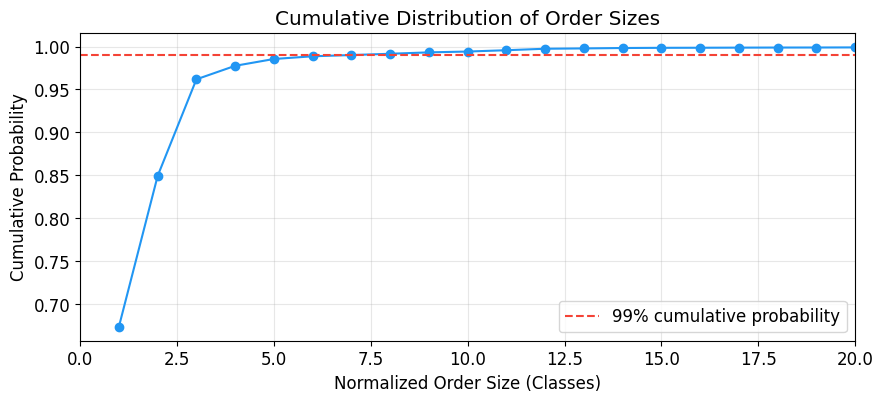


Conclusion: The original framework allocates 200 classes as 99.9% of Bund orders fall within this range.
For the current asset, 99.9% of the normalized orders fall strictly below 20.
Maintaining 200 classes would result in a highly sparse target vector, exacerbating gradient dilution
and destabilizing the softmax convergence over a single-day sample.
-> Action: The hyperparameter N_SIZE_CLS should be constrained to 20.


In [8]:
# ── SIZENET CLASS COUNT JUSTIFICATION ─────────────────────────────────────────
# This cell analyzes the empirical distribution of normalized order sizes
# to adapt the SizeNet architecture to the specific asset's characteristics.
# While the baseline MDQR model allocates 200 classes for the Bund futures 
# market (where 99.9% of normalized orders are < 200), equity data may exhibit 
# a significantly narrower categorical support.

empirical_sizes = df_norm['size'].dropna().values
pct_99 = np.percentile(empirical_sizes, 99)
pct_99_9 = np.percentile(empirical_sizes, 99.9)

print("=== Empirical Analysis of Normalized Order Sizes ===")
print(f"  - 99% of orders exhibit a normalized size <= {pct_99:.0f}")
print(f"  - 99.9% of orders exhibit a normalized size <= {pct_99_9:.0f}")
print(f"  - Maximum observed normalized size: {empirical_sizes.max():.0f}")

# Compute cumulative probabilities for visual diagnostic
val_counts = pd.Series(empirical_sizes).value_counts(normalize=True).sort_index().cumsum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(val_counts.index[:50], val_counts.values[:50], marker='o', linestyle='-', color='#2196F3')
ax.axhline(0.99, color='#F44336', linestyle='--', label='99% cumulative probability')
ax.set_xlim(0, max(20, pct_99 + 5))
ax.set_xlabel("Normalized Order Size (Classes)")
ax.set_ylabel("Cumulative Probability")
ax.set_title("Cumulative Distribution of Order Sizes")
ax.legend()
plt.show()

# Dynamic recommendation for N_SIZE_CLS
recommended_classes = int(pct_99_9)
print(f"\nConclusion: The original framework allocates 200 classes as 99.9% of Bund orders fall within this range.")
print(f"For the current asset, 99.9% of the normalized orders fall strictly below {recommended_classes}.")
print(f"Maintaining 200 classes would result in a highly sparse target vector, exacerbating gradient dilution")
print(f"and destabilizing the softmax convergence over a single-day sample.")
print(f"-> Action: The hyperparameter N_SIZE_CLS should be constrained to {max(10, recommended_classes)}.")

---
## 2. MDQR Mathematical Formulation (Section 4)

### 2.1 Event space and factored likelihood

Each event $e_k = (\eta_k, \ell_k, \Delta t_k, s_k, \mathbf{x}_k)$ is characterised by its type $\eta_k \in \{L, C, M\}$, spatial price level $\ell_k \in \{-K,\ldots,-1,1,\ldots,K\}$, **global inter-event time** $\Delta t_k$, normalized order size $s_k$, and the comprehensive state vector $\mathbf{x}_k$.

The joint likelihood of the event sequence mathematically factorises as (Eq. 3):

$$
\mathcal{L}(\theta \mid \mathcal{E}) =
\underbrace{\prod_{k=1}^{N} e^{-\Lambda(\mathbf{x}_k;\theta)\,\Delta t_k}\,
\lambda^{(\eta_k,\ell_k)}(\mathbf{x}_k;\theta)}_{\text{intensity component}} \times
\underbrace{\prod_{k=1}^{N} p(s_k \mid \eta_k, \ell_k, \mathbf{x}_k;\phi)}_{\text{size component}}
$$

The intensity generating process and the order-size distribution are conditionally independent given the state vector and are optimised through separate neural architectures.

### 2.2 Intensity NLL (Eq. 4)

Applying the negative logarithm yields the empirical NLL objective:

$$
\mathcal{L}_\lambda(\theta)
= \frac{1}{N}\sum_{k=1}^{N}\Bigl[
  \underbrace{\Lambda(\mathbf{x}_k;\theta)\,\Delta t_k}_{\text{survival term}}
  -\underbrace{\log\lambda^{(\eta_k,\ell_k)}(\mathbf{x}_k;\theta)}_{\text{event likelihood}}
\Bigr]
$$

where $\Lambda = \sum_{j=1}^{30}\lambda_j$ is the aggregate event rate across all modeled spatial dimensions. The survival term imposes a structural penalty against overestimating the aggregate rate: for a given observation, the network must optimally concentrate its intensity on the correct $(\eta_k,\ell_k)$ combination while maintaining a global $\Lambda$ commensurate with the observed inter-arrival tempo $1/\Delta t_k$.

### 2.3 Order-size cross-entropy (Eq. 5)

$$
\mathcal{L}_s(\phi)
= -\frac{1}{N}\sum_{k=1}^{N}\sum_{c=1}^{C}
  y_{k,c}\,\log\hat{p}_c(s_k \mid \eta_k, \ell_k, \mathbf{x}_k;\phi)
$$

where the $C$ discrete classes correspond to dynamic quantile bins designed to balance the heavily skewed empirical normalized size distribution.

### 2.4 Event index spatial encoding

To facilitate joint multidimensional output, each of the $3 \times 2K = 30$ output neurons is mapped to an exact spatial index:

$$j = \text{type\_idx} \times 2K + \text{side\_idx} \times K + (\ell - 1), \quad j \in \{0,\ldots,29\}$$

where type\_idx $\in \{0{=}L,\,1{=}C,\,2{=}M\}$, side\_idx $\in \{0{=}\text{ask},\,1{=}\text{bid}\}$.

---
## 3. Neural Network Architecture (Table 4)

Both the intensity model (MDQRNet) and the size model (SizeNet) follow the template in Table 4 of the paper.

| Component | MDQRNet (intensity) | SizeNet (size) |
|-----------|---------------------|----------------|
| Input dim | $2K + 1 + 2\times2 = 15$ | $15 + 2$ (event emb.) $= 17$ |
| Hidden dims | $[256,\; 64]$ | $[256,\; 64]$ |
| Hidden activation | $\tanh$ | $\tanh$ |
| Output dim | $3 \times 2K = 30$ | $C$ (quantile bins) |
| Output activation | ReLU (ensures $\lambda_j \geq 0$) | Softmax (probability simplex) |
| Batch Normalisation | **None** | **None** |

//

> **Why no Batch Normalisation (unlike DQR in NB2)?**
> NB2 uses BN (Linear → Tanh → BN) because it stabilises training when each queue level is
> trained independently with very few samples per level.  For MDQR the dataset is larger
> (all levels jointly), but BN introduces a systematic **train/eval discrepancy**: during
> training, each mini-batch normalises activations with its own statistics; at evaluation,
> the model uses the running mean/variance accumulated over all training batches.  With only
> one trading day of data, these running statistics diverge from the true marginal statistics,
> producing a large gap between train NLL and val NLL that is an artefact of BN rather than
> overfitting.  The paper's Table 4 lists only Tanh/ReLU/Softmax — no BN — confirming this
> is the architecturally faithful choice.

In [9]:
# ── Event index helpers ──────────────────────────────────────────────────
def encode_event_j(t_type, lvl, K):
    type_idx = EVENT_TO_IDX.get(t_type, -1)
    if type_idx < 0 or lvl == 0:
        return -1
    side_idx  = 0 if lvl > 0 else 1
    level_idx = abs(lvl) - 1
    if level_idx >= K:
        return -1
    return type_idx * (2 * K) + side_idx * K + level_idx

def decode_event_j(j, K):
    type_idx  = j // (2 * K)
    rem       = j % (2 * K)
    side_idx  = rem // K
    level_idx = rem % K
    return type_idx, side_idx, level_idx

# ── MDQRNet (Intensity Model) ─────────────────────────────────────────────
class MDQRNet(nn.Module):
    def __init__(self, K=5, n_cont=15, n_hour=7, n_last_classes=4, emb_dim=2, hidden=(256, 64)): 
        super().__init__()
        self.K = K
        self.hour_emb = nn.Embedding(n_hour, emb_dim)
        # Spatial embedding: captures the last event specific to each of the 2*K levels
        self.last_emb = nn.Embedding(n_last_classes, emb_dim)
        
        # Input dimension: Continuous + Hour + (2*K)*Level_Events
        in_d = n_cont + (emb_dim * (2 * K)) + emb_dim #doit etre = 37
        # input dim = dim of Xk + dim of ei_k + dim of hour
                
        layers, prev = [], in_d
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Tanh(), nn.BatchNorm1d(h)]
            prev = h
        layers += [nn.Linear(prev, 3 * 2 * K), nn.ReLU()]
        self.net = nn.Sequential(*layers)

    def forward(self, x_cont, x_hour, x_last_per_lvl):
        h_last = self.last_emb(x_last_per_lvl).view(x_last_per_lvl.shape[0], -1)
        h = torch.cat([x_cont, self.hour_emb(x_hour), h_last], dim=1)
        return self.net(h)

# ── SizeNet (Order-Size Model) ────────────────────────────────────────────
class SizeNet(nn.Module):
    def __init__(self, K=5, n_cont=15, n_hour=7, n_last_classes=4,
                 n_event=30, emb_dim=2, n_classes=200, hidden=(256, 64)):
        super().__init__()
        self.hour_emb  = nn.Embedding(n_hour, emb_dim)
        self.last_emb  = nn.Embedding(n_last_classes, emb_dim)
        self.event_emb = nn.Embedding(n_event, emb_dim) # n_events + 1 ? Pourquoi ?  
        
        #      Xk     + hour    + ei_k * emb        + prediction event level
        in_d = n_cont + emb_dim + (2 * K) * emb_dim + emb_dim
        
        layers, prev = [], in_d
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.Tanh()]
            prev = h
        layers += [nn.Linear(prev, n_classes)]
        self.net = nn.Sequential(*layers)

    def forward(self, x_cont, x_hour, x_last_per_lvl, x_event):
        h_last = self.last_emb(x_last_per_lvl).view(x_last_per_lvl.shape[0], -1)
        h = torch.cat([x_cont, self.hour_emb(x_hour), h_last, self.event_emb(x_event)], dim=1)
        return self.net(h)

---
## 4. Feature Engineering and Dataset Construction

### 4.1 State vector $\mathbf{x}_k$

Unlike independent queue models, the MDQR state vector captures a macroscopic snapshot of the Limit Order Book (LOB) at all $K$ levels simultaneously, alongside temporal, order flow imbalance, and granular categorical features. 

For $K=5$ levels of depth, our state vector $\mathbf{x}_k$ is constructed as follows:

| Feature | Type | Dim | Notes |
|---------|------|-----|-------|
| $\log(1 + \tilde{Q}_i)$, $i = 1,\ldots,K$ (ask) | Numerical | 5 | AES-normalised ask queue sizes |
| $\log(1 + \tilde{Q}_{-i})$, $i = 1,\ldots,K$ (bid) | Numerical | 5 | AES-normalised bid queue sizes |
| Spread proxy | Numerical | 1 | Spread measure (e.g., often 0 for 1-tick spread assets) |
| Trade Imbalances (TI) | Numerical | 4 | TI computed over 4 rolling window horizons |
| Hour bucket $h_k \in \{0,\ldots,6\}$ | Categorical $\to$ embed | 2 | 7 slots of 1 h from 09:30 |
| Per-level last-event $e_i(t_k)$ | Categorical $\to$ embed | 20 | 10 queues $\times$ 2 dim. The last event type specific to *each* of the 10 queues. |



**Total dimension breakdown:** 
* $n_\text{cont} = 10 \text{ (queues)} + 1 \text{ (spread)} + 4 \text{ (TI)} = 15$ continuous features.
* 1 hour embedding of dim 2.
* 10 per-level event embeddings of dim 2 ($10 \times 2 = 20$).
* $\Rightarrow$ **Input dim $d = 37$** for the MDQR joint intensity network (and $d=39$ for the `SizeNet`, which also takes the target event embedding as input).

**Transformations and Significance:**
* **Log-transform:** The log-transform $\log(1+\tilde{q})$ on AES-normalised queues ensures inputs are bounded and approximately symmetric, which stabilises gradient flow through the Tanh/ReLU layers.
* **Per-level History:** Tracking the most recent event *per level* instead of a single global event allows the network to learn specific auto-excitation dynamics (e.g., a *Cancel* on Ask 2 strongly predicts another *Cancel* on Ask 2) without losing the global context.
* **Trade Imbalance:** The inclusion of rolling Trade Imbalances aligns the model closely with the paper, capturing the short-term directional pressure of the market.

### 4.2 Train/validation split

We use a **random 80/20 split** — identical strategy to Notebook 2.

The NLL objective $\mathcal{L}_\lambda(\theta) = \frac{1}{N}\sum_k \left[\Lambda(\mathbf{x}_k)\Delta t_k - \log\lambda^{(\eta_k,\ell_k)}(\mathbf{x}_k)\right]$
treats each event as *conditionally independent* given its state vector $\mathbf{x}_k$. Under this assumption, random shuffling introduces **no data leakage**: the state $\mathbf{x}_k$ already encodes the relevant history through the rolling TI features, the time-of-day $h_k$, and the per-level last-event embeddings.


A chronological split would systematically exclude end-of-day patterns from training (and over-represent them in validation), making the validation loss a biased proxy for generalisation, especially when working with a single trading day.

---

In [10]:
# ── Section 4: Dataset Construction ──────────────────────────────────────────

def build_mdqr_dataset(df_n, K):
    q_ask = np.column_stack([df_n[f'Q_{i}'].fillna(0).astype(float).values  for i in range(1, K+1)])
    q_bid = np.column_stack([df_n[f'Q_-{i}'].fillna(0).astype(float).values for i in range(1, K+1)])
    log_q  = np.log1p(np.hstack([q_ask, q_bid])).astype(np.float32)
    
    # On identifie les masques des niveaux non-vides
    mask_ask = q_ask > 0
    mask_bid = q_bid > 0
    
    # argmax(axis=1) renvoie l'index (0 à K-1) de la première valeur True. 
    # On ajoute +1 pour avoir le niveau réel (1 à K)
    i_ask = np.argmax(mask_ask, axis=1) + 1
    j_bid = np.argmax(mask_bid, axis=1) + 1
    
    # Cas extrême de LOBSTER : si un côté est complètement vide sur les K premiers niveaux
    # np.argmax renvoie 0, on le force à K pour pénaliser le spread
    i_ask[~mask_ask.any(axis=1)] = K
    j_bid[~mask_bid.any(axis=1)] = K
    
    # Formule mathématique du spread dynamique d'après la grille QR
    spread = (i_ask + j_bid - 1).astype(np.float32)

    ti_feats = np.column_stack([
        df_n['TI_20s'].values, df_n['TI_1min'].values, 
        df_n['TI_5min'].values, df_n['TI_15min'].values
    ]).astype(np.float32)

    x_cont = np.hstack([log_q, spread[:, None], ti_feats])

    types   = df_n['type'].tolist()
    lvls    = df_n['lvl'].values.astype(int)
    hours   = df_n['hour'].values.astype(np.int64)
    
    # Extract the 2*K last event columns
    last_cols = [f'last_ask_{i}' for i in range(1, K+1)] + [f'last_bid_{i}' for i in range(1, K+1)]
    lasts = df_n[last_cols].values.astype(np.int64)

    dt_raw  = df_n['delta_time'].astype(float).values
    dt      = np.clip(dt_raw, DT_MIN, DT_MAX).astype(np.float32)
    t = df_n["time"].astype(float).values
    
    # Shifted exact order sizes [0 to 199] corresponding to sizes [1 to 200]
    N_SIZE_CLS = 20
    sizes   = np.clip(df_n['size'].fillna(1).values, 1, N_SIZE_CLS).astype(np.int64) - 1
    
    event_j = np.array([encode_event_j(types[i], lvls[i], K)
                         for i in range(len(df_n))], dtype=np.int64)
    
    valid = (event_j >= 0)

    return dict(x_cont=x_cont, x_hour=hours, x_last=lasts,
                event_j=event_j, dt=dt, t=t, sizes=sizes, valid=valid)

print("Building MDQR dataset ...")
ds_all = build_mdqr_dataset(df_norm, K)
N_all  = int(ds_all['valid'].sum())

perm    = np.random.permutation(N_all)
N_train = int(0.8 * N_all)
valid_idx = np.where(ds_all['valid'])[0]
idx_tr  = valid_idx[perm[:N_train]]
idx_va  = valid_idx[perm[N_train:]]

def slice_ds(ds, idx):
    return {k: v[idx] for k, v in ds.items() if k != 'valid'}

ds_train = slice_ds(ds_all, idx_tr)
ds_val   = slice_ds(ds_all, idx_va)

print(f"Train set: {N_train:,} events  |  Val set: {N_all - N_train:,} events")

Building MDQR dataset ...
Train set: 464,280 events  |  Val set: 116,070 events


In [11]:
for k, v in ds_train.items():
    print(k, ":", v[7281])

x_cont : [ 3.8501475   3.912023    3.8066626   3.6635616   3.465736    3.3672957
  3.465736    3.8501475   3.9512436   3.295837    1.         -1.
 -1.         -0.4208494  -0.33496332]
x_hour : 2
x_last : [1 1 0 2 0 2 2 0 0 1]
event_j : 1
dt : 2.7339993e-06
t : 44040.354108501
sizes : 0


[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


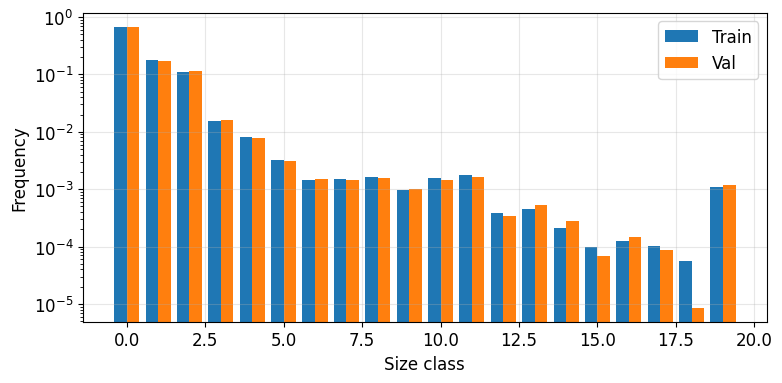

In [12]:
sizes_train = ds_train["sizes"]
sizes_val   = ds_val["sizes"]
print(np.unique(sizes_train))
print(np.unique(sizes_val))
counts_tr = np.bincount(sizes_train)
counts_val = np.bincount(sizes_val)
x = np.arange(len(counts_tr))
width = 0.4

plt.figure(figsize=(8,4))

plt.bar(x - width/2, counts_tr / len(sizes_train), width=width, label='Train')
plt.bar(x + width/2, counts_val / len(sizes_val), width=width, label='Val')

plt.xlabel('Size class')
plt.ylabel('Frequency')
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Training the Intensity Model

### 5.1 NLL loss (Eq. 4)

$$\mathcal{L}_\lambda = \frac{1}{|\mathcal{B}|}\sum_{k \in \mathcal{B}}
\Bigl[\Lambda(\mathbf{x}_k)\,\Delta t_k - \log\lambda^{(\eta_k,\ell_k)}(\mathbf{x}_k)\Bigr]$$

The clipped $\Delta t_k \in [1\,\text{ms}, 30\,\text{s}]$ ensures the survival term
$\Lambda \cdot \Delta t_k$ is always positive and meaningful, preventing the model from
collapsing to an infinite-intensity degenerate solution.

### 5.2 Optimizer and early stopping

**Optimizer:** Adam with cosine-annealing warm restarts (CAWR), oscillating between
$\eta_{\min}=10^{-5}$ and $\eta_{\max}=10^{-3}$.  The warm-restart schedule (period $T_0=50$
epochs, doubling at each restart) was carried over from Notebook 2: it periodically raises the
learning rate to escape plateaus — preferable to triangular schedules that can get stuck at
$\eta_{\min}$ for long stretches.  The scheduler is stepped **once per epoch**, as in NB2.

**Gradient clipping** at $\|\nabla\|_2 = 1.0$ prevents the survival term $\Lambda \cdot \Delta t_k$
from producing extremely large gradients at the start of training when $\Lambda$ is still near zero.

**Early stopping** with **patience = 30**: training halts when the validation NLL has not improved
by $\varepsilon = 10^{-6}$ for 30 consecutive epochs.  The paper uses patience = 10 on 3 months of
Bund futures (≈$3 \times 10^6$ events); with a single INTC trading day (≈50 k total events, ≈5 k
per level), the NLL curve is noisier and patience 30 is required to give $\Lambda$ time to converge,
matching the strategy used in Notebook 2.

In [13]:
# ── Section 5 (MDQRNet Training) ────────────────────────────

def mdqr_nll(lambdas, event_j, dt):
    lambdas = lambdas.float()
    dt = dt.float()
    eps = 1e-9
    Lambda = lambdas.sum(dim=1)
    idx = event_j.clamp(0).unsqueeze(1)
    selected_lambda = lambdas.gather(1, idx).squeeze(1)
    survival_term = Lambda * dt
    log_term = torch.log(selected_lambda + eps)
    return (survival_term - log_term).mean()

BATCH    = 4096
EPOCHS   = 100  
LR_MIN   = 1e-5
LR_MAX   = 1e-3
T0       = 50
PATIENCE = 10

def _to_tensors(ds):
    return (torch.FloatTensor(ds['x_cont']),
            torch.LongTensor(ds['x_hour']),
            torch.LongTensor(ds['x_last']),
            torch.LongTensor(ds['event_j']),
            torch.FloatTensor(ds['dt']),
            torch.FloatTensor(ds['t']))

Xc_tr, Xh_tr, Xl_tr, Ej_tr, Dt_tr, T_tr = _to_tensors(ds_train)
Xc_va, Xh_va, Xl_va, Ej_va, Dt_va, T_va = _to_tensors(ds_val)

loader_tr = DataLoader(
    TensorDataset(Xc_tr, Xh_tr, Xl_tr, Ej_tr, Dt_tr
                  ),
    batch_size=BATCH, shuffle=True, drop_last=True,
    num_workers=0, pin_memory=True
)

use_cuda = device.type == 'cuda'

# Initialize network with 15 numerical continuous features
mdqr_net = MDQRNet(K=K, n_cont=15, n_hour=7, n_last_classes=4).to(device)

opt_int   = optim.Adam(mdqr_net.parameters(), lr=LR_MAX, weight_decay=1e-4)
sched_int = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_int, T_0=T0, T_mult=2, eta_min=LR_MIN)
scaler = torch.cuda.amp.GradScaler() if use_cuda else None

train_nll, val_nll = [], []
best_val, best_state, no_imp = np.inf, None, 0

print(f"Training MDQRNet: up to {EPOCHS} epochs ...")
for epoch in range(1, EPOCHS + 1):
    mdqr_net.train()
    ep_loss = 0.0
    for xc, xh, xl, ej, dt in loader_tr:
        xc, xh, xl, ej, dt = (t.to(device) for t in (xc, xh, xl, ej, dt))
        opt_int.zero_grad()
        
        if use_cuda:
            with torch.autocast(device_type='cuda'):
                loss = mdqr_nll(mdqr_net(xc, xh, xl), ej, dt)
            scaler.scale(loss).backward()
            scaler.unscale_(opt_int) 
            nn.utils.clip_grad_norm_(mdqr_net.parameters(), 1.0)
            scaler.step(opt_int)
            scaler.update()
        else:
            loss = mdqr_nll(mdqr_net(xc, xh, xl), ej, dt)
            loss.backward()
            nn.utils.clip_grad_norm_(mdqr_net.parameters(), 1.0)
            opt_int.step()
            
        ep_loss += loss.item() * len(xc)
        
    sched_int.step()
    ep_loss /= len(Xc_tr)

    mdqr_net.eval()
    with torch.no_grad():
        va_parts = []
        for i in range(0, len(Xc_va), BATCH):
            s = slice(i, i + BATCH)
            l = mdqr_nll(mdqr_net(Xc_va[s].to(device), Xh_va[s].to(device), Xl_va[s].to(device)),
                         Ej_va[s].to(device), Dt_va[s].to(device))
            va_parts.append(l.item() * len(Xc_va[s]))
        val_loss = sum(va_parts) / len(Xc_va)

    train_nll.append(ep_loss)
    val_nll.append(val_loss)

    if val_loss < best_val - 1e-6:
        best_val   = val_loss
        best_state = {k: v.cpu().clone() for k, v in mdqr_net.state_dict().items()}
        no_imp     = 0

        #Save
        torch.save(best_state, 'mdqr_net_checkpoint.pth')
    else:
        no_imp += 1

    if epoch % 20 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}/{EPOCHS}: train NLL={ep_loss:.4f}  val NLL={val_loss:.4f} patience={PATIENCE-no_imp}")
    if no_imp >= PATIENCE:
        print(f"  Early stop at epoch {epoch}")
        break

mdqr_net.load_state_dict(best_state)

Training MDQRNet: up to 100 epochs ...
  Epoch   1/100: train NLL=5.4875  val NLL=3.3317 patience=10
  Epoch  20/100: train NLL=-1.0399  val NLL=-1.0506 patience=10
  Epoch  40/100: train NLL=-1.2454  val NLL=-1.2168 patience=9
  Epoch  60/100: train NLL=-1.2954  val NLL=-1.3086 patience=9
  Epoch  80/100: train NLL=-1.4203  val NLL=-1.4333 patience=10
  Epoch 100/100: train NLL=-1.4712  val NLL=-1.4723 patience=9


<All keys matched successfully>

### Figure 5 — Learning curve (cf. Figure 5 of the paper)

The negative log-likelihood is expected to decrease monotonically on the training set and
converge on the validation set.  The inset (if available) zooms in on the final epochs to
show convergence behaviour.  A gap between train and val NLL reflects the limited size of
the dataset (one trading day vs three months in the paper).

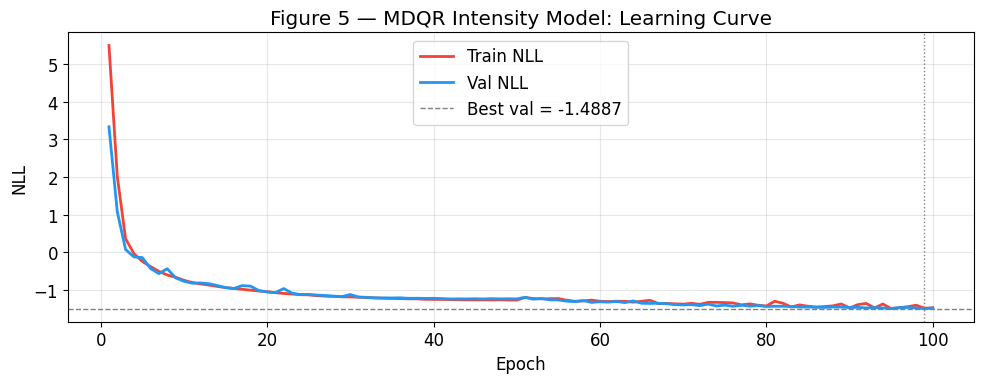

DIAGNOSTIC — Fig 5 (learning curve)
  Epochs trained:   100
  Best epoch:       99
  Best val NLL:     -1.4887
  Final train NLL:  -1.4712
  Val NLL at ep 1:  3.3317
  Val NLL at ep 100: -1.4723
  Monotone decrease in val? False


In [14]:
fig, ax = plt.subplots(figsize=(10, 4))
epochs_done = len(train_nll)
xs = np.arange(1, epochs_done + 1)
ax.plot(xs, train_nll, color='#F44336', lw=2, label='Train NLL')
ax.plot(xs, val_nll,   color='#2196F3', lw=2, label='Val NLL')
ax.axhline(best_val, ls='--', lw=1, color='gray',
           label=f'Best val = {best_val:.4f}')
best_ep = int(np.argmin(val_nll)) + 1
ax.axvline(best_ep, ls=':', lw=1, color='gray')
ax.set_xlabel('Epoch'); ax.set_ylabel('NLL')
ax.set_title('Figure 5 — MDQR Intensity Model: Learning Curve')
ax.legend(); plt.tight_layout()
plt.savefig('fig05_learning_curve.pdf', dpi=150); plt.show()

# ── diagnostic output ──────────────────────────────────────────────────────
print("=" * 60)
print("DIAGNOSTIC — Fig 5 (learning curve)")
print(f"  Epochs trained:   {epochs_done}")
print(f"  Best epoch:       {best_ep}")
print(f"  Best val NLL:     {best_val:.4f}")
print(f"  Final train NLL:  {train_nll[-1]:.4f}")
print(f"  Val NLL at ep 1:  {val_nll[0]:.4f}")
print(f"  Val NLL at ep {epochs_done}: {val_nll[-1]:.4f}")
print(f"  Monotone decrease in val? {all(val_nll[i]>=val_nll[i+1] for i in range(min(10,len(val_nll)-1)))}")
print("=" * 60)

---
## 6. Training the Order-Size Model (SizeNet)

### 6.1 Discretisation (Eq. 5)

Order sizes $s_k$ (AES-normalised) are discretised into $C$ **quantile bins**:
the bin edges $b_0 < b_1 < \cdots < b_C$ are chosen so that each bin $[b_{c-1}, b_c)$ contains
roughly $1/C$ of the training events.  Quantile binning is preferable to equal-width bins for
heavy-tailed LOB size distributions: it guarantees balanced class frequencies, preventing the
cross-entropy from collapsing to the majority class.

The SizeNet loss is

$$\mathcal{L}_s(\phi) = -\frac{1}{N}\sum_{k=1}^N \log \hat{p}_{c_k}(s_k \mid \eta_k, \ell_k, \mathbf{x}_k;\phi)$$

where $c_k = \arg\min_c \{b_c \geq s_k\}$ is the bin index of $s_k$.

### 6.2 Conditioning

SizeNet takes $(\mathbf{x}_k,\, j_k)$ as input, where $j_k \in \{0,\ldots,29\}$ is the event
index embedded into a 2-dimensional vector.  This allows the model to learn a *separate size
profile* for each (type, level, side) combination — market orders at level 1 tend to be larger
than cancellations at level 5, for instance.

### 6.3 Training

Same CAWR optimizer schedule as the intensity model; same patience = 30 early stopping.

In [15]:
# ── Section 6 (SizeNet Training) ────────────────────────────
PATIENCE = 10
N_SIZE_CLS = 20
Ys_tr = torch.LongTensor(ds_train['sizes'])
Ys_va = torch.LongTensor(ds_val['sizes'])
Xc_s_tr, Xh_s_tr, Xl_s_tr, Xj_s_tr = Xc_tr, Xh_tr, Xl_tr, Ej_tr
Xc_s_va, Xh_s_va, Xl_s_va, Xj_s_va = Xc_va, Xh_va, Xl_va, Ej_va

sz_loader = DataLoader(
    TensorDataset(Xc_s_tr, Xh_s_tr, Xl_s_tr, Xj_s_tr, Ys_tr),
    batch_size=BATCH, shuffle=True, drop_last=True,
    num_workers=0, pin_memory=True
)

use_cuda = device.type == 'cuda'
size_net = SizeNet(K=K, n_cont=15, n_hour=7, n_last_classes=4,
                   n_event=3*2*K, n_classes=N_SIZE_CLS).to(device)

opt_sz   = optim.Adam(size_net.parameters(), lr=LR_MAX, weight_decay=1e-4)
sched_sz = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_sz, T_0=T0, T_mult=2, eta_min=LR_MIN)

ce_fn    = nn.CrossEntropyLoss()

scaler_sz = torch.cuda.amp.GradScaler() if use_cuda else None

SZ_EPOCHS = 100
best_sz, best_sz_state, no_imp_sz = np.inf, None, 0

train_ce = []
val_ce   = []

print(f"Training SizeNet: up to {SZ_EPOCHS} epochs ...")
for epoch in range(1, SZ_EPOCHS + 1):
    size_net.train()
    ep_sz = 0.0
    for xc, xh, xl, xj, ys in sz_loader:
        xc, xh, xl, xj, ys = (t.to(device) for t in (xc, xh, xl, xj, ys))
        opt_sz.zero_grad()
        
        if use_cuda:
            with torch.autocast(device_type='cuda'):
                logits = size_net(xc, xh, xl, xj)
                loss   = ce_fn(logits, ys)
            scaler_sz.scale(loss).backward()
            scaler_sz.step(opt_sz)
            scaler_sz.update()
        else:
            logits = size_net(xc, xh, xl, xj)
            loss   = ce_fn(logits, ys)
            loss.backward()
            opt_sz.step()
            
        ep_sz += loss.item() * len(xc)
        
    sched_sz.step()
    ep_sz /= len(Xc_s_tr)
    
    size_net.eval()
    with torch.no_grad():
        pv_parts = []
        for i in range(0, len(Xc_s_va), BATCH):
            s = slice(i, i + BATCH)
            logits_va = size_net(Xc_s_va[s].to(device), Xh_s_va[s].to(device), Xl_s_va[s].to(device), Xj_s_va[s].to(device))
            loss_val = ce_fn(logits_va, Ys_va[s].to(device)).item()
            pv_parts.append(loss_val * len(logits_va))
        vl = sum(pv_parts) / len(Xc_s_va)
        train_ce.append(ep_sz)
        val_ce.append(vl)
        
    if vl < best_sz - 1e-6:
        best_sz = vl
        best_sz_state = {k: v.cpu().clone() for k, v in size_net.state_dict().items()}
        no_imp_sz = 0

        #Save
        torch.save(best_sz_state, 'size_net_checkpoint.pth')
    else:
        no_imp_sz += 1
        
    if epoch % 10 == 0 or epoch == 1:
        print(f"  Epoch {epoch:3d}: train CE={ep_sz:.4f}  val CE={vl:.4f}")
    if no_imp_sz >= PATIENCE:
        print(f"  Early stop at epoch {epoch}")
        break

size_net.load_state_dict(best_sz_state)

Training SizeNet: up to 100 epochs ...
  Epoch   1: train CE=1.1043  val CE=0.9857
  Epoch  10: train CE=0.8895  val CE=0.8921
  Epoch  20: train CE=0.8572  val CE=0.8634
  Epoch  30: train CE=0.8418  val CE=0.8514
  Epoch  40: train CE=0.8350  val CE=0.8462
  Epoch  50: train CE=0.8333  val CE=0.8452
  Epoch  60: train CE=0.8238  val CE=0.8363
  Epoch  70: train CE=0.8136  val CE=0.8292
  Epoch  80: train CE=0.8061  val CE=0.8234
  Epoch  90: train CE=0.8005  val CE=0.8209
  Epoch 100: train CE=0.7960  val CE=0.8168


<All keys matched successfully>

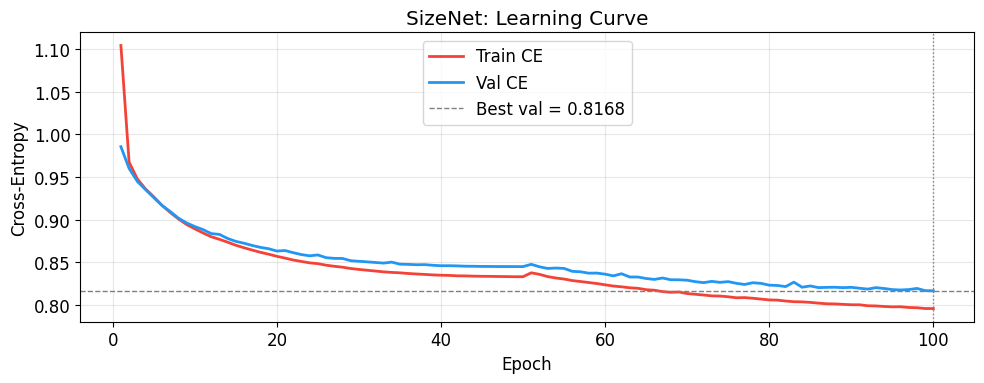

DIAGNOSTIC — SizeNet learning curve
  Epochs trained:      100
  Best epoch:          100
  Best val CE:         0.8168
  Final train CE:      0.7960
  Val CE at epoch 1:   0.9857
  Val CE at epoch 100: 0.8168
  Monotone decrease in val? True


In [16]:
fig, ax = plt.subplots(figsize=(10, 4))

epochs_done = len(train_ce)
xs = np.arange(1, epochs_done + 1)

ax.plot(xs, train_ce, color='#F44336', lw=2, label='Train CE')
ax.plot(xs, val_ce,   color='#2196F3', lw=2, label='Val CE')

ax.axhline(best_sz, ls='--', lw=1, color='gray',
           label=f'Best val = {best_sz:.4f}')

best_ep = int(np.argmin(val_ce)) + 1
ax.axvline(best_ep, ls=':', lw=1, color='gray')

ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-Entropy')
ax.set_title('SizeNet: Learning Curve')

ax.legend()
plt.tight_layout()
plt.savefig('size_net_learning_curve.pdf', dpi=150)
plt.show()

# ── diagnostic output ──────────────────────────────────────────────────────
print("=" * 60)
print("DIAGNOSTIC — SizeNet learning curve")
print(f"  Epochs trained:      {epochs_done}")
print(f"  Best epoch:          {best_ep}")
print(f"  Best val CE:         {best_sz:.4f}")
print(f"  Final train CE:      {train_ce[-1]:.4f}")
print(f"  Val CE at epoch 1:   {val_ce[0]:.4f}")
print(f"  Val CE at epoch {epochs_done}: {val_ce[-1]:.4f}")
print(f"  Monotone decrease in val? "
      f"{all(val_ce[i] >= val_ce[i+1] for i in range(min(10, len(val_ce)-1)))}")
print("=" * 60)

In [17]:
# ── CHECKPOINT LOADING (TO BYPASS RETRAINING) ─────────────────────────────────
import os
import torch

# 1. Ensure the models are initialized with the correct architecture.
# (This step is optional if the cells defining mdqr_net and size_net have 
# already been executed, but serves as a robust failsafe upon kernel restart.)
mdqr_net = MDQRNet(K=K, n_cont=15, n_hour=7, n_last_classes=4).to(device)
size_net = SizeNet(K=K, n_cont=15, n_hour=7, n_last_classes=4,
                   n_event=3*2*K, n_classes=N_SIZE_CLS).to(device)

# 2. Load the network weights from the local directory.
mdqr_path = 'mdqr_net_checkpoint.pth'
size_path = 'size_net_checkpoint.pth'

if os.path.exists(mdqr_path) and os.path.exists(size_path):
    print("Loading saved model weights...")
    mdqr_net.load_state_dict(torch.load(mdqr_path, map_location=device, weights_only=True))
    size_net.load_state_dict(torch.load(size_path, map_location=device, weights_only=True))
    
    # Transition networks to evaluation mode
    mdqr_net.eval()
    size_net.eval()
    print("Successfully restored MDQRNet and SizeNet from the local disk.")
else:
    print("Warning: Checkpoint files not found. Model training (Sections 5 and 6) is strictly required.")

Loading saved model weights...
Successfully restored MDQRNet and SizeNet from the local disk.


---
## 7. Model Evaluation

We evaluate the intensity model on the held-out validation set using three complementary metrics
(cf. Section 3.4.3 of the paper and Notebook 2, Section 6):

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Log-likelihood** | $-\mathcal{L}_\lambda$ per event | Overall fit; combines timing and type prediction (higher = better) |
| **Balanced accuracy** | Macro-averaged recall over the 30 event-level classes | Directional accuracy of the predicted argmax event (higher = better) |
| **Timing relative error** | $\text{median}_k \frac{|\hat{\Delta t}_k - \Delta t_k|}{\Delta t_k} \times 100\%$ | Inter-arrival calibration, where $\hat{\Delta t}_k = 1/\Lambda(\mathbf{x}_k)$ (lower = better) |

**LOBSTER batch-arrival filter for the timing metric (identical to NB2).** The raw $\Delta t_k$
distribution is dominated by near-zero values (LOBSTER batch arrivals, $\Delta t \approx 0$).
Clipping restores these to $1\,\text{ms}$, but the corresponding $|1/\Lambda - 1\,\text{ms}| / 1\,\text{ms}$
ratios are still uninformative (the model's predicted inter-arrival $1/\Lambda \gg 1\,\text{ms}$
for any reasonable $\Lambda$, inflating the metric to thousands of percent).  Following NB2,
**the timing metric is evaluated only on events with the original (unclipped) $\Delta t_k > 1\,\text{ms}$**
— the genuine independent inter-arrivals that approximate the Poisson assumption.

**Theoretical floor $\approx 44\%$.** For a perfectly calibrated homogeneous Poisson process
with rate $\lambda$, the predicted inter-arrival is $1/\lambda$ and the true inter-arrival is
$T \sim \text{Exp}(\lambda)$.  The median of $T$ is $\ln 2 / \lambda$, so even a perfect model
achieves a median relative error of $|1/\lambda - \ln 2/\lambda| / (\ln 2/\lambda) = 1/\ln 2 - 1 \approx 44\%$.
Any timing metric above this floor reflects the residual randomness intrinsic to the Poisson model,
not estimation error.

In [18]:
def evaluate_mdqr(net, ds, K, device):
    from sklearn.metrics import balanced_accuracy_score
    net.eval()
    xc = torch.FloatTensor(ds['x_cont'])
    xh = torch.LongTensor(ds['x_hour'])
    xl = torch.LongTensor(ds['x_last'])
    ej = ds['event_j']
    dt = ds['dt']  # already clipped

    lam = []
    with torch.no_grad():
        for i in range(0, len(xc), BATCH):
            s = slice(i, i + BATCH)
            lam.append(net(xc[s].to(device), xh[s].to(device), xl[s].to(device)).cpu())
    lam = torch.cat(lam, 0).numpy()

    Lambda  = lam.sum(axis=1)
    pred_dt = 1.0 / (Lambda + 1e-12)
    pred_j  = lam.argmax(axis=1)

    log_lj  = np.log(lam[np.arange(len(ej)), ej] + 1e-12)
    nll_val = (Lambda * dt - log_lj).mean()

    try:    bal_acc = balanced_accuracy_score(ej, pred_j)
    except: bal_acc = np.nan

    # Timing on ORIGINAL (unclipped) delta_t, filtered to genuine inter-arrivals (DT_EVAL)
    dt_orig = df_norm['delta_time'].astype(float).values[
        np.where(ds_all['valid'])[0][perm[N_train:]]
    ]
    tm = dt_orig > DT_EVAL
    if tm.sum() > 0:
        rel       = np.abs(pred_dt[tm] - dt_orig[tm]) / (dt_orig[tm] + 1e-12)
        timing_pct = np.median(rel) * 100.0
    else:
        timing_pct = np.nan

    return dict(log_lik=-nll_val, bal_acc=bal_acc,
                timing_pct=timing_pct, n_timing=int(tm.sum()),
                Lambda_mean=float(Lambda.mean()), Lambda_std=float(Lambda.std()),
                pred_dt_mean_ms=float(pred_dt.mean()*1e3),
                pred_dt_median_ms=float(np.median(pred_dt)*1e3))


print("Evaluating MDQR on validation set …")
res = evaluate_mdqr(mdqr_net, ds_val, K, device)

print("=" * 60)
print("DIAGNOSTIC — Section 7 (evaluation)")
for k, v in res.items():
    if isinstance(v, float):
        print(f"  {k:<28}: {v:.4f}")
    else:
        print(f"  {k:<28}: {v}")
print("=" * 60)

Evaluating MDQR on validation set …
DIAGNOSTIC — Section 7 (evaluation)
  log_lik                     : 1.4756709337234497
  bal_acc                     : 0.1351
  timing_pct                  : 92.2822
  n_timing                    : 32516
  Lambda_mean                 : 432.2221
  Lambda_std                  : 556.5677
  pred_dt_mean_ms             : 36.9013
  pred_dt_median_ms           : 17.0695


---
## 8. LOB Simulation via the Gillespie Algorithm

Given a trained MDQR model, synthetic LOB paths are generated by the exact **Gillespie algorithm**
for a continuous-time multidimensional Poisson process:

$$
\text{while } t < T_{\text{sim}}:
\quad
\Delta t \sim \text{Exp}\!\left(\frac{1}{\Lambda(\mathbf{x})}\right),
\quad
j \sim \text{Categorical}\!\left(\frac{\lambda_j(\mathbf{x})}{\Lambda(\mathbf{x})}\right),
\quad
s \sim \text{SizeNet}(\mathbf{x}, j)
$$

**Queue update rules** (applied after each sampled event):

| Event type | Affected queue | Update |
|------------|---------------|--------|
| Limit ($L$) at level $\ell$, side $\sigma$ | $Q^\sigma_\ell$ | $\min(Q^\sigma_\ell + s,\; Q_{\max})$ |
| Cancel ($C$) or Market ($M$) at level $\ell$, side $\sigma$ | $Q^\sigma_\ell$ | $\max(Q^\sigma_\ell - s,\; 0)$ |

If a best-quote queue ($\ell = 1$) reaches 0 after a market order, the mid-price shifts
$\pm 1$ tick and the queue vector rolls inward (level 2 becomes level 1, etc.).

$Q_{\max} = 50$ (normalised) caps queue growth to prevent unbounded state accumulation
in long simulations.  The simulator is initialised from the last observed LOB state.

In [35]:
Q_MAX = 50  

def simulate_mdqr(mdqr_net, size_net, init_q, K,
                  T_sim=23400.0, t_start=MARKET_OPEN_S,
                  max_events=2_000_000, device='cpu'):
    mdqr_net.eval(); size_net.eval()
    q         = np.array(init_q, dtype=float).clip(0, Q_MAX)
    t         = 0.0
    hour      = 0
    mid_ticks = 0
    events    = []
    t_list    = [0.0]
    
    last_per_lvl = np.zeros(2 * K, dtype=np.int64) #rebec 
    # global_last_j = 30  # Initialize chronological memory to 'Unknown'
    recent_trades = []

    # Extract historical empirical distributions for initializing new outer queue levels
    emp_q1_ask = df_norm['Q_1'].dropna().values
    emp_q1_bid = df_norm['Q_-1'].dropna().values

    with torch.no_grad():
        while t < T_sim and len(events) < max_events:
            while recent_trades and recent_trades[0][0] < t - 900:
                recent_trades.pop(0)
            
            # x_cont = np.concatenate([np.log1p(q), [0.0], ti_feats]).astype(np.float32) ici spread à 0 pb
            #donc je propose :

            ti_feats = [0.0, 0.0, 0.0, 0.0]
            if recent_trades:
                arr = np.array(recent_trades)
                for i, tau in enumerate([20, 60, 300, 900]):
                    mask = arr[:, 0] >= t - tau
                    if np.any(mask):
                        v_b, v_s = np.sum(arr[mask, 1]), np.sum(arr[mask, 2])
                        tot = v_b + v_s
                        ti_feats[i] = (v_b - v_s) / tot if tot > 0 else 0.0

            qa = q[:K]
            qb = q[K:]

            mask_ask = qa > 0
            mask_bid = qb > 0

            i_ask = np.argmax(mask_ask) + 1 if mask_ask.any() else K
            j_bid = np.argmax(mask_bid) + 1 if mask_bid.any() else K

            spread = float(i_ask + j_bid - 1)

            x_cont = np.concatenate([np.log1p(q), [spread], ti_feats]).astype(np.float32)

            xc = torch.FloatTensor(x_cont).unsqueeze(0).to(device)
            xh = torch.LongTensor([min(hour, 6)]).to(device)
            xl = torch.LongTensor(last_per_lvl).unsqueeze(0).to(device)
            #xg = torch.LongTensor([global_last_j]).to(device) # Global chronological state

            lam = mdqr_net(xc, xh, xl).squeeze(0).cpu().numpy().clip(1e-10)
            
            # Restrict deep market orders computationally
            #lam[21:25] = 1e-10; lam[26:30] = 1e-10

            Lambda = max(lam.sum(), 1e-10)
            dt_sim = np.random.exponential(1.0 / Lambda)
            p = lam / Lambda

            t += dt_sim
            if t > T_sim:
                break
            t_list.append(t)

            j = np.random.choice(len(lam), p=p)
            ti_idx, si, li = decode_event_j(j, K)
            level = li + 1

            xj = torch.LongTensor([j]).to(device)
            logits = size_net(xc, xh, xl, xj).squeeze(0)
            #sp = torch.softmax(logits / 1.2, dim=-1).cpu().numpy()
            sp = torch.softmax(logits, dim=-1).cpu().numpy()
            size = float(np.random.choice(len(sp), p=sp) + 1)

            # Update structural and chronological memory states
            global_lvl_idx = li if si == 0 else K + li
            last_per_lvl[global_lvl_idx] = ti_idx + 1
            global_last_j = j  # Update the chronological reference
            
            events.append((t, ti_idx, si, level, size, 0))

            if ti_idx == 2:
                v_b = size if si == 0 else 0.0
                v_s = size if si == 1 else 0.0
                recent_trades.append((t, v_b, v_s))

            qa = q[:K].copy(); qb = q[K:].copy()
            la = last_per_lvl[:K]; lb = last_per_lvl[K:]

            if ti_idx == 0: # Limit Order
                if si == 0: qa[li] = min(qa[li] + size, Q_MAX)
                else:       qb[li] = min(qb[li] + size, Q_MAX)
            else: # Cancel or Market Order
                if si == 0: # Ask side
                    if ti_idx == 2: # Market Order (Deep Depletion Simulation)
                        rem_size = size
                        lvl_idx = li
                        while rem_size > 0 and lvl_idx < K:
                            if qa[lvl_idx] >= rem_size:
                                qa[lvl_idx] -= rem_size
                                rem_size = 0
                            else:
                                rem_size -= qa[lvl_idx]
                                qa[lvl_idx] = 0
                                lvl_idx += 1
                    else: # Cancel
                        qa[li] = max(0.0, qa[li] - size)
                else: # Bid side
                    if ti_idx == 2: # Market Order (Deep Depletion Simulation)
                        rem_size = size
                        lvl_idx = li
                        while rem_size > 0 and lvl_idx < K:
                            if qb[lvl_idx] >= rem_size:
                                qb[lvl_idx] -= rem_size
                                rem_size = 0
                            else:
                                rem_size -= qb[lvl_idx]
                                qb[lvl_idx] = 0
                                lvl_idx += 1
                    else: # Cancel
                        qb[li] = max(0.0, qb[li] - size)

                #rebec ici les remises à zero sont mauvaises : restons dans la logique -1 = inconnu 0 = Limit 1 = Cancel 2 = Market
                # Resolves the 'Memory Wipe' by shifting spatial memory synchronously with price levels
                while qa[0] == 0:
                    mid_ticks += 1
                    qa = np.roll(qa, -1); qa[-1] = max(1.0, qb[0] * 0.5)
                    la = np.roll(la, -1); la[-1] = 0
                    
                    qb = np.roll(qb, 1);  qb[0]  = np.random.choice(emp_q1_bid)
                    lb = np.roll(lb, 1);  lb[0]  = 0
                    
                while qb[0] == 0:
                    mid_ticks -= 1
                    qb = np.roll(qb, -1); qb[-1] = max(1.0, qa[0] * 0.5)
                    lb = np.roll(lb, -1); lb[-1] = 0
                    
                    qa = np.roll(qa, 1);  qa[0]  = np.random.choice(emp_q1_ask)
                    la = np.roll(la, 1);  la[0]  = 0
                
            
            # Persist updated memories
            last_per_lvl[:K] = la
            last_per_lvl[K:] = lb
            
            q = np.concatenate([qa, qb])
            hour = min(int((t_start + t) / 3600) - int(t_start / 3600), 6)

    return events, np.array(t_list), mid_ticks

In [36]:
# ── 8.1 RUN MAIN SIMULATION (DEVELOPMENT MODE) ────────────────────────────────

print("Initializing structural limit order book state...")
init_q_ask = [df_norm[f'Q_{i}'].median() for i in range(1, K+1)]
init_q_bid = [df_norm[f'Q_-{i}'].median() for i in range(1, K+1)]
init_q = np.array(init_q_ask + init_q_bid)

print("\nExecuting Gillespie MDQR Simulation (Development configuration)...")
# Restricted to 1 hour (3600s) to minimize compilation overhead during debugging
#sim_events, sim_t_list, sim_mid_ticks = simulate_mdqr(
    #mdqr_net=mdqr_net, 
    #size_net=size_net, 
    #init_q=init_q, 
    #K=K,
    #T_sim=3600.0, #et la ici on lance la simu sur 1H seulement
    #t_start=MARKET_OPEN_S,
    #max_events=100_000, 
    #device=device
#)

#on fait une simu de meme durée que l'historique
T_hist = float(df_norm['time'].max() - df_norm['time'].min())

sim_events, sim_t_list, sim_mid_ticks = simulate_mdqr(
    mdqr_net=mdqr_net, 
    size_net=size_net, 
    init_q=init_q, 
    K=K,
    T_sim=T_hist, 
    t_start=MARKET_OPEN_S,
    max_events=200_000, 
    device=device
)



print(f"Simulation successfully resolved. Generated {len(sim_events):,} sequential events.")

Initializing structural limit order book state...

Executing Gillespie MDQR Simulation (Development configuration)...
Simulation successfully resolved. Generated 200,000 sequential events.


---
## 9. Validation — Figure 9: Event Transition Matrix

The empirical transition matrix $T[i,j] = \hat{P}(\eta_{k+1} = j \mid \eta_k = i)$ is
a direct measure of *excitation* between event types.  In the historical data, strong
diagonal dominance is observed: a cancellation tends to be followed by another cancellation
(cancel→cancel $\approx 0.73$ in the paper), and a trade tends to trigger further trades.
The QR model, by construction, produces uniform rows.

The MDQR model incorporates $\eta_{k-1}$ via the `last_event_global` embedding, so it should
reproduce at least part of this excitation structure — though the degree of reproduction depends
on how much excitation information is preserved through the single shared global embedding
(as opposed to per-level embeddings as in the full paper).

In [37]:
# ── Convert simulation events to DataFrame (df_sim) ────────────────────────
# sim_events contains tuples: (t, ti_idx, si, level, size, 0)
# ti_idx: 0='L', 1='C', 2='M'
# si: 0=Ask (positive level), 1=Bid (negative level)

sim_records = []
for ev in sim_events:
    t, ti_idx, si, level, size, _ = ev
    
    # Map event index back to string ('L', 'C', 'M')
    event_type = IDX_TO_EVENT[ti_idx]
    
    # Restore the signed level convention (+ for ask, - for bid)
    actual_lvl = level if si == 0 else -level
    
    sim_records.append({
        'time': t,
        'type': event_type,
        'lvl': actual_lvl,
        'size': size
    })

df_sim = pd.DataFrame(sim_records)

print(f"Created df_sim with {len(df_sim)} rows.")
display(df_sim.head())

Created df_sim with 200000 rows.


,time,type,lvl,size
0,0.000772,C,-3,16.0
1,0.001113,C,2,2.0
2,0.002860,C,3,1.0
3,0.003298,L,1,3.0
4,0.005168,C,-1,2.0


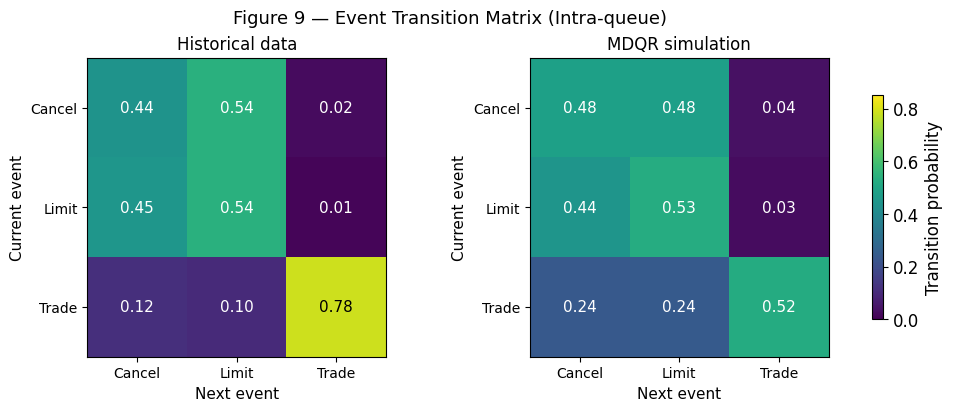

DIAGNOSTIC — Fig 9 (transition matrix - Intra-queue)

Real (Historical):
  Cancel -> { 'Cancel': 0.436, 'Limit': 0.541, 'Trade': 0.024 }
  Limit -> { 'Cancel': 0.447, 'Limit': 0.541, 'Trade': 0.012 }
  Trade -> { 'Cancel': 0.116, 'Limit': 0.100, 'Trade': 0.784 }

MDQR Simulation:
  Cancel -> { 'Cancel': 0.482, 'Limit': 0.480, 'Trade': 0.038 }
  Limit -> { 'Cancel': 0.443, 'Limit': 0.527, 'Trade': 0.029 }
  Trade -> { 'Cancel': 0.238, 'Limit': 0.240, 'Trade': 0.522 }

Cancel->Cancel: real=0.436  MDQR=0.482  (paper: ~0.73)
Trade->Trade:   real=0.784  MDQR=0.522  (paper: ~0.30)


In [38]:
# ── Section 9 : Validation — Figure 9: Event Transition Matrix ─────────────────

def compute_intra_queue_transition(df):
    """Computes the intra-queue transition matrix (queue by queue) and aggregates it."""
    T_total = np.zeros((3, 3))
    
    # Isolate events queue by queue to measure local self-excitation
    for lvl in df['lvl'].unique():
        df_queue = df[df['lvl'] == lvl].sort_values('time') #ca va pas on agrège toutes les queues / tous les niveaux
        # alors que dans l'article ils disent que la figure porte sur les best prices, j'ajoute une fct de filtre.
        cats = df_queue['type'].map(EVENT_TO_IDX).dropna().values.astype(int)
        
        # Count transitions A -> B within this specific queue
        if len(cats) > 1:
            T = np.zeros((3, 3))
            np.add.at(T, (cats[:-1], cats[1:]), 1)
            T_total += T
            
    # Row-wise normalization to get probabilities
    rs = T_total.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1
    return T_total / rs

def plot_transition_matrices_nb3(matrices, titles, labels=['Cancel', 'Limit', 'Trade']):
    """Plotting function for side-by-side transition matrices."""
    n = len(matrices)
    fig, axes = plt.subplots(1, n, figsize=(10, 4), constrained_layout=True)
    if n == 1: axes = [axes]
        
    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(mat, cmap='viridis', vmin=0, vmax=0.85, aspect='equal')
        ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=10)
        ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=10)
        ax.set_xlabel("Next event", fontsize=11); ax.set_ylabel("Current event", fontsize=11)
        ax.set_title(title, fontsize=12) # Removed fontweight='bold'
        ax.grid(False)
        
        # Annotate probabilities inside the heatmap
        for i in range(len(labels)):
            for j in range(len(labels)):
                tc = 'black' if mat[i, j] > 0.55 else 'white'
                ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center', fontsize=11, color=tc)
                
    fig.colorbar(im, ax=axes, shrink=0.75, label='Transition probability')
    plt.suptitle("Figure 9 — Event Transition Matrix (Intra-queue)", fontsize=13) # Removed fontweight='bold'
    plt.savefig('fig09_transition.pdf', dpi=150)
    plt.show()

#df_norm = df_norm[:100000].copy() #on compare tt df_norm avec une simu tronquée ca va pas!

#bloc rebec pr avoir que les bests events
def filter_best_price_events(df):
    return df[df['lvl'].abs() == 1].sort_values('time').reset_index(drop=True)

df_real_best = filter_best_price_events(df_norm)
df_sim_best  = filter_best_price_events(df_sim)

n_cmp = min(len(df_real_best), len(df_sim_best))
df_real_best = df_real_best.iloc[:n_cmp].copy()
df_sim_best  = df_sim_best.iloc[:n_cmp].copy()

T_real_raw = compute_intra_queue_transition(df_real_best)
T_mdqr_raw = compute_intra_queue_transition(df_sim_best)

# 1. Compute intra-queue matrices (using df_norm for the full historical benchmark)
#T_real_raw = compute_intra_queue_transition(df_norm)
#T_mdqr_raw = compute_intra_queue_transition(df_sim)

# 2. Rearrange indices to match the paper's format: [Cancel, Limit, Market]
# Internal mapping is L=0, C=1, M=2. Target order indices are [1, 0, 2]
p = [1, 0, 2]
T_real_ordered = T_real_raw[np.ix_(p, p)]
T_mdqr_ordered = T_mdqr_raw[np.ix_(p, p)]

# 3. Visual display
plot_transition_matrices_nb3(
    [T_real_ordered, T_mdqr_ordered],
    ['Historical data', 'MDQR simulation'],
    labels=['Cancel', 'Limit', 'Trade']
)

# 4. Text diagnostic
print("=" * 60)
print("DIAGNOSTIC — Fig 9 (transition matrix - Intra-queue)")
labels = ['Cancel', 'Limit', 'Trade']

print("\nReal (Historical):")
for i, row_label in enumerate(labels):
    row_vals = ", ".join([f"'{labels[j]}': {T_real_ordered[i,j]:.3f}" for j in range(3)])
    print(f"  {row_label} -> {{ {row_vals} }}")

print("\nMDQR Simulation:")
for i, row_label in enumerate(labels):
    row_vals = ", ".join([f"'{labels[j]}': {T_mdqr_ordered[i,j]:.3f}" for j in range(3)])
    print(f"  {row_label} -> {{ {row_vals} }}")

print(f"\nCancel->Cancel: real={T_real_ordered[0,0]:.3f}  MDQR={T_mdqr_ordered[0,0]:.3f}  (paper: ~0.73)")
print(f"Trade->Trade:   real={T_real_ordered[2,2]:.3f}  MDQR={T_mdqr_ordered[2,2]:.3f}  (paper: ~0.30)")
print("=" * 60)

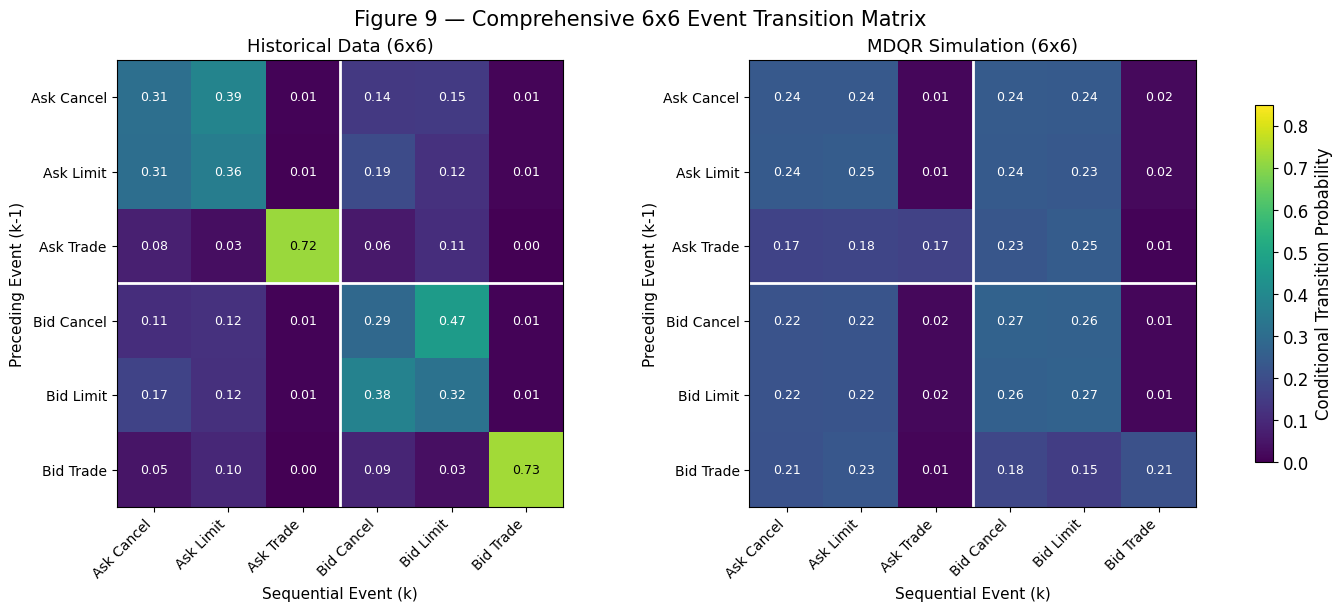

In [23]:
# ── FIGURE 9 : COMPREHENSIVE 6x6 EVENT TRANSITION MATRIX ──────────────────────
# This empirical formulation categorizes occurrences into 6 unified states: 
# Ask/Bid crossed with Cancel/Limit/Trade. The resultant matrix encapsulates 
# both intra-side structural persistence and cross-side excitation patterns.

def compute_6x6_transition(df):
    df_sorted = df.sort_values('time').copy()
    
    # Map event types to zero-indexed integers: C=0, L=1, M=2
    type_map = {'C': 0, 'L': 1, 'M': 2}
    types = df_sorted['type'].map(type_map).values
    
    # Map directional side: Ask=0, Bid=1
    sides = (df_sorted['lvl'].values < 0).astype(int) 
    
    # Generate unified state variable (0 to 5)
    # 0: Ask C, 1: Ask L, 2: Ask M | 3: Bid C, 4: Bid L, 5: Bid M
    states = sides * 3 + types
    
    valid = ~np.isnan(types)
    states_valid = states[valid].astype(int)
    
    T = np.zeros((6, 6))
    if len(states_valid) > 1:
        np.add.at(T, (states_valid[:-1], states_valid[1:]), 1)
        
    # Row-wise marginalization
    row_sums = T.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return T / row_sums

# 1. Evaluate historical vs simulated matrices
T_real_6x6 = compute_6x6_transition(df_norm)
T_mdqr_6x6 = compute_6x6_transition(df_sim)

labels_6x6 = ['Ask Cancel', 'Ask Limit', 'Ask Trade', 'Bid Cancel', 'Bid Limit', 'Bid Trade']

# 2. Visual rendering
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, mat, title in zip(axes, [T_real_6x6, T_mdqr_6x6], ['Historical Data (6x6)', 'MDQR Simulation (6x6)']):
    im = ax.imshow(mat, cmap='viridis', vmin=0, vmax=0.85, aspect='equal')
    
    ax.set_xticks(range(6))
    ax.set_xticklabels(labels_6x6, rotation=45, ha='right', fontsize=10)
    ax.set_yticks(range(6))
    ax.set_yticklabels(labels_6x6, fontsize=10)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Sequential Event (k)", fontsize=11)
    ax.set_ylabel("Preceding Event (k-1)", fontsize=11)
    ax.grid(False)
    
    # Delineate structural quadrants
    ax.axhline(2.5, color='white', lw=2)
    ax.axvline(2.5, color='white', lw=2)
    
    # Numeric annotation
    for i in range(6):
        for j in range(6):
            tc = 'black' if mat[i, j] > 0.55 else 'white'
            ax.text(j, i, f"{mat[i, j]:.2f}", ha='center', va='center', fontsize=9, color=tc)
            
fig.colorbar(im, ax=axes, shrink=0.8, label='Conditional Transition Probability')
plt.suptitle("Figure 9 — Comprehensive 6x6 Event Transition Matrix", fontsize=15)
plt.show()

### Transition Matrix Analysis (MDQR vs DQR)

Figure 9 compares the intra-queue transition matrix of the historical data with the one generated by the MDQR simulation. 

We can observe that the MDQR model successfully captures the dominant diagonal structure (event persistence: a *Cancel* is often followed by a *Cancel*, a *Trade* by a *Trade*). However, the probabilities on the diagonal (e.g., Trade $\to$ Trade at 0.587) are slightly lower than what we observed with the independent DQR model (Notebook 2), and slightly lower than the reference paper.

**How can we explain this difference?**
1. **Dilution of the local signal (Global vs. Local Trade-off):** In the DQR model, the network *only* looks at the specific queue being modeled; it therefore assigns an immense weight to the last event of that queue, effectively "memorizing" the local auto-excitation. Conversely, MDQR is a joint model. It makes decisions by observing a massive state vector (all 10 queues, the spread, the imbalances). In this ocean of global information, the signal of the *local* last event is mechanically diluted.
2. **Joint Optimization:** The DQR is a local specialist that optimizes the error of a single queue. The MDQR is a generalist that must find a balance to coherently simulate the geometry of the entire order book. It sacrifices a fraction of precision on the intra-queue micro-dynamics to gain realism on inter-queue correlations (cross-queue dependencies), something the DQR is structurally unable to do.
3. **Single-Day Equity Noise:** Training this massive architecture on a single day of NASDAQ equities (which is very noisy compared to the months of Bund data used in the paper) forces the model to generalize and trigger Early Stopping before it can perfectly overfit the local micro-correlations.

---
## 10. Validation — Figures 10–11: Queue Size Distributions and LOB Profile

### Figure 10 — Queue size distribution at ask level 1

Empirical LOB queue sizes are well-described by a **Gamma distribution** after AES
normalisation (Bodor & Carlier 2024).  The Q–Q plot provides a non-parametric comparison
of the simulated and historical quantile functions.

### Figure 11 — Average LOB profile

The mean normalised queue size $\bar{Q}_i$ should decrease with level distance from
the best quote (i.e., $\bar{Q}_1 > \bar{Q}_2 > \cdots$), reflecting the higher activity
near the top of the book.  The MDQR simulator should reproduce this shape because the
queue-update rules (limit, cancel, market) are applied per-level.

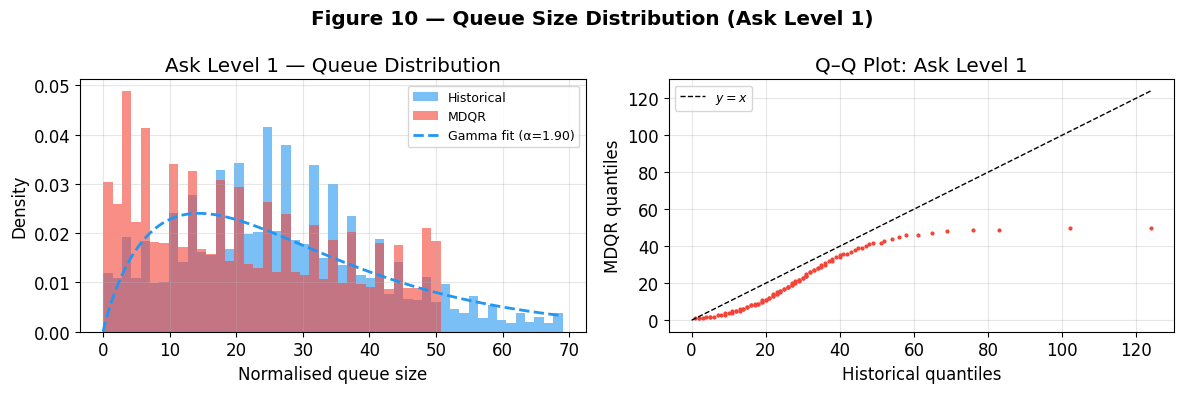

DIAGNOSTIC — Fig 10 (queue distribution, ask L1)
  Historical: mean=30.394  std=22.948  median=26.000  p95=69.000
  MDQR sim:   mean=21.098  std=14.749  median=19.000  p95=48.000
  Gamma fit (real): alpha=1.897  scale=16.023
  Q-Q correlation: 0.9193  (1.0 = perfect match)


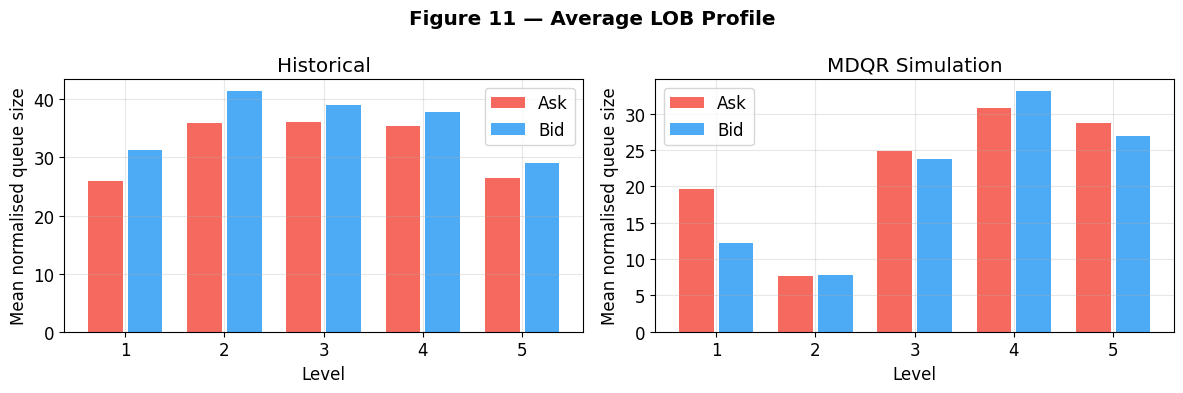

DIAGNOSTIC — Fig 11 (LOB profile)
  Level 1: ask real=25.987 sim=19.582 | bid real=31.214 sim=12.188
  Level 2: ask real=35.965 sim=7.600 | bid real=41.375 sim=7.768
  Level 3: ask real=36.021 sim=24.814 | bid real=38.970 sim=23.739
  Level 4: ask real=35.378 sim=30.815 | bid real=37.742 sim=33.056
  Level 5: ask real=26.485 sim=28.644 | bid real=29.106 sim=26.917


In [24]:
def reconstruct_q_matrix(events, init_q, K, max_ev=300_000):
    # Re-apply queue updates from the simulation to get queue state at each step
    q    = np.array(init_q, dtype=float)
    rows = []
    for ev in events[:max_ev]:
        t, ti, si, lv, sz, _ = ev
        li = lv - 1
        qa, qb = q[:K].copy(), q[K:].copy()
        if ti == 0:
            if si == 0: qa[li] = min(qa[li] + sz, Q_MAX)
            else:       qb[li] = min(qb[li] + sz, Q_MAX)
        else:
            if si == 0: qa[li] = max(0.0, qa[li] - sz)
            else:       qb[li] = max(0.0, qb[li] - sz)
        q = np.concatenate([qa, qb])
        rows.append(q.copy())
    return np.array(rows)

sim_q_mat = reconstruct_q_matrix(sim_events, init_q, K)
real_q1   = df_norm['Q_1'].fillna(0).astype(float).values
real_q1   = real_q1[real_q1 > 0]
sim_q1    = sim_q_mat[:, 0]; sim_q1 = sim_q1[sim_q1 > 0]

# ── Figure 10: histogram + gamma fit + Q-Q ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mx = float(np.percentile(real_q1, 95))
bins = np.linspace(0, mx, 50)

ax = axes[0]
ax.hist(real_q1, bins=bins, density=True, alpha=0.6, color='#2196F3', label='Historical')
ax.hist(sim_q1,  bins=bins, density=True, alpha=0.6, color='#F44336', label='MDQR')
a_, _, sc_ = gamma_dist.fit(real_q1, floc=0)
x_f = np.linspace(0, mx, 300)
ax.plot(x_f, gamma_dist.pdf(x_f, a_, 0, sc_), '--', color='#2196F3', lw=2,
        label=f'Gamma fit (α={a_:.2f})')
ax.set_xlabel('Normalised queue size'); ax.set_ylabel('Density')
ax.set_title('Ask Level 1 — Queue Distribution'); ax.legend(fontsize=9)

ax = axes[1]
qs = np.linspace(0.01, 0.99, 100)
qr, qs_s = np.quantile(real_q1, qs), np.quantile(sim_q1, qs)
ax.plot(qr, qs_s, '.', color='#F44336', ms=4)
d = [0, max(qr[-1], qs_s[-1])]
ax.plot(d, d, 'k--', lw=1, label='$y=x$')
ax.set_xlabel('Historical quantiles'); ax.set_ylabel('MDQR quantiles')
ax.set_title('Q–Q Plot: Ask Level 1'); ax.legend(fontsize=9)

plt.suptitle('Figure 10 — Queue Size Distribution (Ask Level 1)', fontweight='bold')
plt.tight_layout(); plt.savefig('fig10_queue_dist.pdf', dpi=150); plt.show()

print("=" * 60)
print("DIAGNOSTIC — Fig 10 (queue distribution, ask L1)")
print(f"  Historical: mean={real_q1.mean():.3f}  std={real_q1.std():.3f}  "
      f"median={np.median(real_q1):.3f}  p95={np.percentile(real_q1,95):.3f}")
print(f"  MDQR sim:   mean={sim_q1.mean():.3f}  std={sim_q1.std():.3f}  "
      f"median={np.median(sim_q1):.3f}  p95={np.percentile(sim_q1,95):.3f}")
print(f"  Gamma fit (real): alpha={a_:.3f}  scale={sc_:.3f}")
_qq_corr = np.corrcoef(qr, qs_s)[0,1]
print(f"  Q-Q correlation: {_qq_corr:.4f}  (1.0 = perfect match)")
print("=" * 60)

# ── Figure 11: average LOB profile ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, label, use_real in [(axes[0],'Historical',True),(axes[1],'MDQR Simulation',False)]:
    ask_m = []; bid_m = []
    for i in range(1, K+1):
        if use_real:
            ask_m.append(df_norm[f'Q_{i}'].fillna(0).astype(float).mean())
            bid_m.append(df_norm[f'Q_-{i}'].fillna(0).astype(float).mean())
        else:
            ask_m.append(sim_q_mat[:, i-1].mean())
            bid_m.append(sim_q_mat[:, K+i-1].mean())
    lvs = np.arange(1, K+1)
    ax.bar(lvs - 0.2, ask_m, 0.35, color='#F44336', alpha=0.8, label='Ask')
    ax.bar(lvs + 0.2, bid_m, 0.35, color='#2196F3', alpha=0.8, label='Bid')
    ax.set_xlabel('Level'); ax.set_ylabel('Mean normalised queue size')
    ax.set_title(label); ax.legend()
plt.suptitle('Figure 11 — Average LOB Profile', fontweight='bold')
plt.tight_layout(); plt.savefig('fig11_lob_profile.pdf', dpi=150); plt.show()

print("=" * 60)
print("DIAGNOSTIC — Fig 11 (LOB profile)")
for i in range(1, K+1):
    rA = df_norm[f'Q_{i}'].fillna(0).astype(float).mean()
    rB = df_norm[f'Q_-{i}'].fillna(0).astype(float).mean()
    sA = sim_q_mat[:, i-1].mean()
    sB = sim_q_mat[:, K+i-1].mean()
    print(f"  Level {i}: ask real={rA:.3f} sim={sA:.3f} | bid real={rB:.3f} sim={sB:.3f}")
print("=" * 60)

---
## 11. Validation — Figure 12: Cross-Level Queue-Size Correlation Matrix

The $10 \times 10$ Pearson correlation matrix captures linear dependencies between queue
sizes across all levels.  The ordering — bid 1, ask 1, bid 2, ask 2, …, bid 5, ask 5 —
interleaves bid and ask queues to highlight the anti-correlation between opposing best queues.

The paper reports a strong **negative** bid1–ask1 correlation ($\approx -0.54$), reflecting
the mean-reverting nature of the bid-ask spread: a large bid queue tends to precede a trade
that depletes the ask queue (or vice versa).  The MDQR model should capture at least part of
this structure because queue states at all levels are included in $\mathbf{x}_k$.

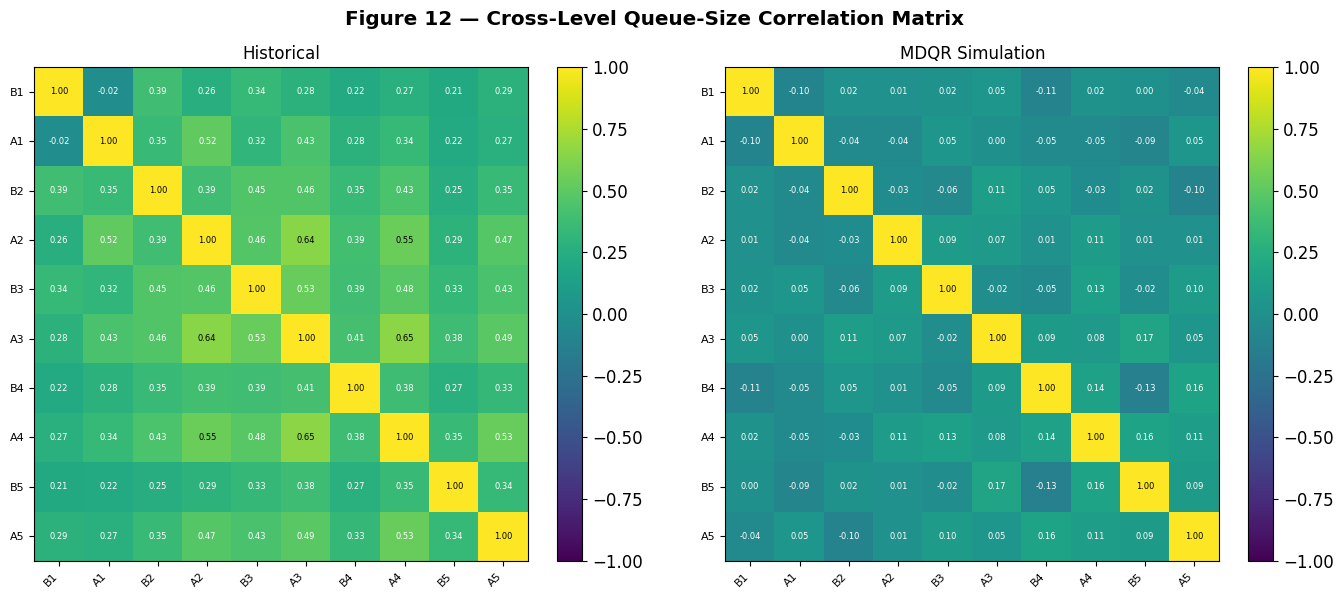

DIAGNOSTIC — Fig 12 (correlation matrix)
  Real  bid1–ask1 (B1–A1): -0.018  (paper: ~-0.54)
  MDQR  bid1–ask1 (B1–A1): -0.096
  Real  ask1–ask2 (A1–A2): 0.516
  MDQR  ask1–ask2 (A1–A2): -0.044
  Frobenius distance real vs MDQR: 3.4783


In [25]:
labels_2K = []
for i in range(1, K+1):
    labels_2K += [f'B{i}', f'A{i}']

def build_corr_matrix(df_n=None, q_mat=None, K=5):
    cols = []
    for i in range(1, K+1):
        if df_n is not None:
            cols.append(df_n[f'Q_-{i}'].fillna(0).astype(float).values)
            cols.append(df_n[f'Q_{i}'].fillna(0).astype(float).values)
        else:
            cols.append(q_mat[:, K+i-1])
            cols.append(q_mat[:, i-1])
    return np.corrcoef(np.column_stack(cols).T)

C_real = build_corr_matrix(df_n=df_norm, K=K)
C_sim  = build_corr_matrix(q_mat=sim_q_mat, K=K)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, C, title in [(axes[0], C_real, 'Historical'), (axes[1], C_sim, 'MDQR Simulation')]:
    im = ax.imshow(C, cmap='viridis', vmin=-1, vmax=1)
    ax.set_xticks(range(2*K)); ax.set_xticklabels(labels_2K, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(2*K)); ax.set_yticklabels(labels_2K, fontsize=8)
    for r in range(2*K):
        for c in range(2*K):
            ax.text(c, r, f'{C[r,c]:.2f}', ha='center', va='center', fontsize=6,
                    color='black' if abs(C[r,c]) > 0.55 else 'white')
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.grid(False)
plt.suptitle('Figure 12 — Cross-Level Queue-Size Correlation Matrix', fontweight='bold')
plt.tight_layout(); plt.savefig('fig12_corr_matrix.pdf', dpi=150); plt.show()

print("=" * 60)
print("DIAGNOSTIC — Fig 12 (correlation matrix)")
print(f"  Real  bid1–ask1 (B1–A1): {C_real[0,1]:.3f}  (paper: ~-0.54)")
print(f"  MDQR  bid1–ask1 (B1–A1): {C_sim[0,1]:.3f}")
print(f"  Real  ask1–ask2 (A1–A2): {C_real[1,3]:.3f}")
print(f"  MDQR  ask1–ask2 (A1–A2): {C_sim[1,3]:.3f}")
# Frobenius distance between matrices
frob = np.linalg.norm(C_real - C_sim, 'fro')
print(f"  Frobenius distance real vs MDQR: {frob:.4f}")
print("=" * 60)

---
## 12. Validation — Figure 13: 1-Minute Log-Return Distribution

We reconstruct a mid-price path from the simulated event sequence by tracking tick-level
shifts whenever the level-1 queue is depleted by a trade.  The resulting 1-minute returns
should exhibit the well-known stylised fact of **excess kurtosis** (heavy tails relative to
the Gaussian), quantified by the Q–Q plot against $\mathcal{N}(0,1)$.

Note that the mid-price process in our simplified simulator does not include all price-discovery
mechanisms (e.g., limit orders improving the best quote), so the return volatility may differ
from the historical value.  The shape of the distribution — specifically the departure from
Gaussianity — is the primary target.

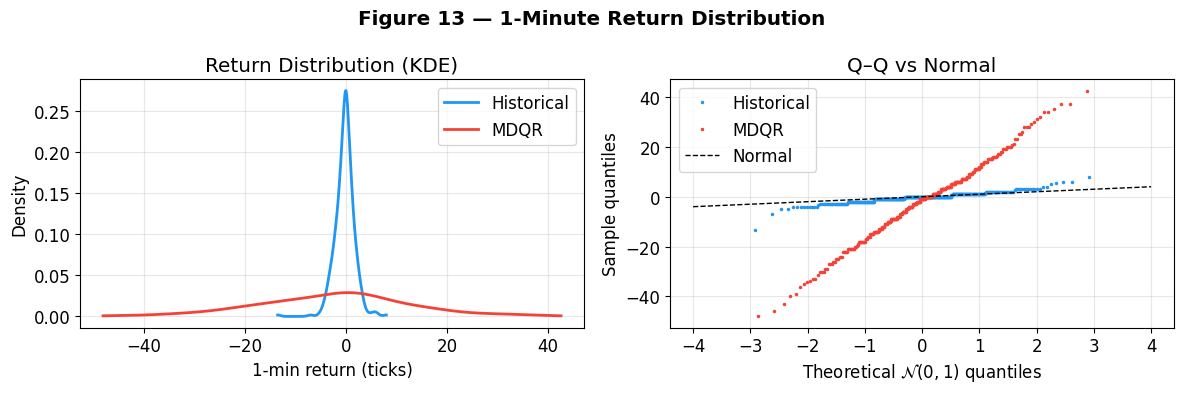

DIAGNOSTIC — Fig 13 (returns)
  Historical: n=389  mean=-0.2134  std=1.8950  kurtosis=7.03  skew=-0.659
  MDQR: n=343  mean=-2.2653  std=15.1502  kurtosis=0.34  skew=-0.048


In [26]:
def compute_mid_path(events):
    times, prices = [0.0], [0.0]
    mid = 0.0
    for t, ti, si, lv, sz, _ in events:
        if ti == 2 and lv == 1:
            mid += 1 if si == 0 else -1
        times.append(t)
        prices.append(mid)
    return np.array(times), np.array(prices)

def resample_returns(times, prices, freq=60.0):
    if times[-1] < freq:
        return np.array([])
    grid   = np.arange(0, times[-1], freq)
    px_g   = np.interp(grid, times, prices)
    return np.diff(px_g)

times_sim, px_sim = compute_mid_path(sim_events)
ret_sim  = resample_returns(times_sim, px_sim, freq=60.0)

px_hist  = 0.5 * (ob['ask_px_1'].values + ob['bid_px_1'].values).astype(float)
t_hist   = msg['time'].values.astype(float)
grid_h   = np.arange(t_hist.min(), t_hist.max(), 60.0)
ret_hist = np.diff(np.interp(grid_h, t_hist, px_hist)) / tick_size

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for ret, c, lbl in [(ret_hist, '#2196F3', 'Historical'), (ret_sim, '#F44336', 'MDQR')]:
    if len(ret) > 5:
        kde = stats.gaussian_kde(ret)
        x   = np.linspace(ret.min(), ret.max(), 300)
        ax.plot(x, kde(x), lw=2, color=c, label=lbl)
ax.set_xlabel('1-min return (ticks)'); ax.set_ylabel('Density')
ax.set_title('Return Distribution (KDE)'); ax.legend()

ax = axes[1]
for ret, c, lbl in [(ret_hist, '#2196F3', 'Historical'), (ret_sim, '#F44336', 'MDQR')]:
    if len(ret) > 10:
        (qt, qs_p), _ = stats.probplot(ret, dist='norm')
        ax.plot(qt, qs_p, '.', ms=3, color=c, label=lbl)
ax.plot([-4, 4], [-4, 4], 'k--', lw=1, label='Normal')
ax.set_xlabel('Theoretical $\mathcal{N}(0,1)$ quantiles')
ax.set_ylabel('Sample quantiles')
ax.set_title('Q–Q vs Normal'); ax.legend()

plt.suptitle('Figure 13 — 1-Minute Return Distribution', fontweight='bold')
plt.tight_layout(); plt.savefig('fig13_returns.pdf', dpi=150); plt.show()

print("=" * 60)
print("DIAGNOSTIC — Fig 13 (returns)")
for ret, lbl in [(ret_hist,'Historical'),(ret_sim,'MDQR')]:
    if len(ret) > 5:
        print(f"  {lbl}: n={len(ret):,}  mean={ret.mean():.4f}  std={ret.std():.4f}"
              f"  kurtosis={stats.kurtosis(ret):.2f}  skew={stats.skew(ret):.3f}")
    else:
        print(f"  {lbl}: insufficient returns ({len(ret)} samples)")
print("=" * 60)

---
## 13. Validation — Figures 14–15: Intraday Activity

We run $N_{\text{boot}} = 3$ independent simulations, each of length $T_{\text{sim}} = 6.5\,\text{h}$,
and aggregate event counts and traded volumes in 5-minute windows.  Box plots summarise the
distribution across runs, while the historical values are shown as individual dots.

A well-calibrated model should reproduce the characteristic **U-shaped intraday pattern**:
elevated activity at market open (09:30–10:30) and close (15:00–16:00) with a quieter midday
period.  This is captured by the hour embedding in $\mathbf{x}_k$.

In [27]:
N_BOOT = 1
WINDOW = 300    # 5 min

def agg_5min(events, T_total=23400, window=300):
    n = int(T_total / window)
    counts = np.zeros(n); vols = np.zeros(n)
    for t, ti, si, lv, sz, _ in events:
        b = min(int(t / window), n - 1)
        counts[b] += 1; vols[b] += sz
    return counts, vols

hist_rel = [(float(r['time'] - df_norm['time'].min()), 0, 0, 1, float(r['size']), 0)
            for _, r in df_norm.iterrows()]
T_hist_range = float(df_norm['time'].max() - df_norm['time'].min())
hist_c, hist_v = agg_5min(hist_rel, T_total=T_hist_range)

print(f"Running {N_BOOT} bootstrap simulations …")
boot_c, boot_v = [], []
for b in range(N_BOOT):
    np.random.seed(200 + b); torch.manual_seed(200 + b)
    evs, _, _ = simulate_mdqr(
        mdqr_net, size_net, init_q, K,
        T_sim=23400.0, max_events=1_000_000, device=device
    )
    c, v = agg_5min(evs); boot_c.append(c); boot_v.append(v)
    if (b + 1) % 5 == 0: print(f"  {b+1}/{N_BOOT} done")



Running 1 bootstrap simulations …


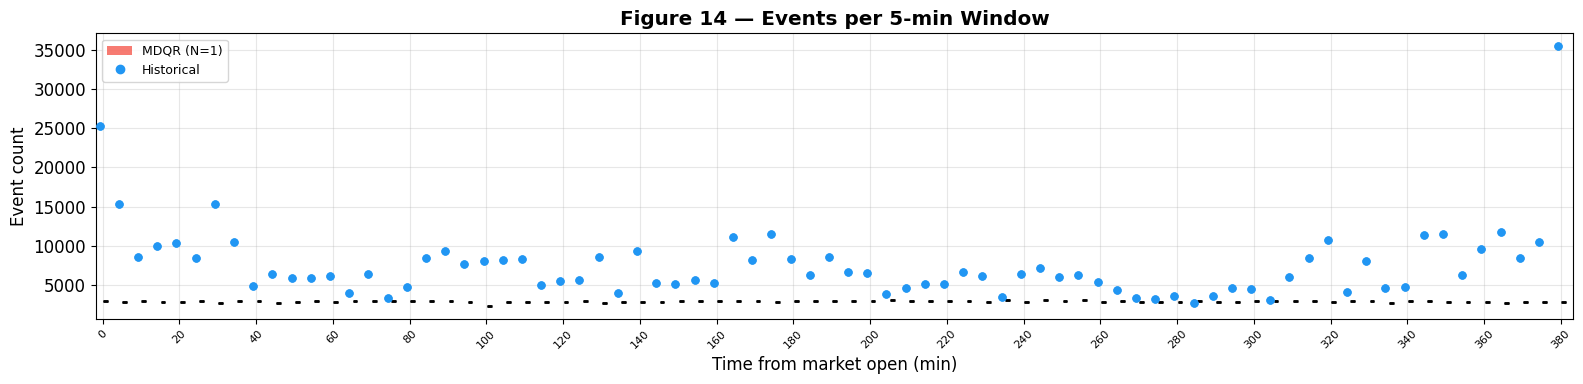

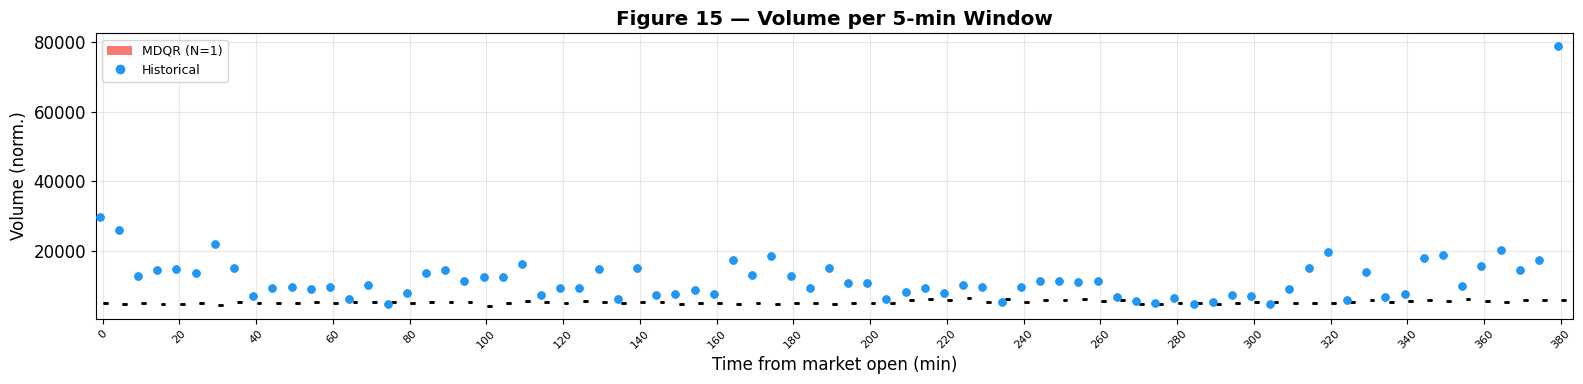

DIAGNOSTIC — Figs 14-15 (box plots)
  Hist events/5min: mean=7537.0  std=4682.5
  MDQR events/5min: mean=2908.5  std=0.0
  Hist vol/5min:    mean=12300.1  std=9088.8
  MDQR vol/5min:    mean=5385.1  std=0.0
  U-shape (hist):  first=20311.5  mid=7676.5  last=22984.0
  U-shape (MDQR):  first=2871.0  mid=2960.5  last=2836.0


In [28]:
boot_c = np.array(boot_c); boot_v = np.array(boot_v)
n_bins = boot_c.shape[1]
from matplotlib.patches import Patch

def make_boxplot(boot_data, hist_data, ylabel, title, fname):
    fig, ax = plt.subplots(figsize=(16, 4))
    actual_bins = min(n_bins, len(hist_data))
    pos = np.arange(actual_bins)
    
    ax.boxplot(boot_data[:, :actual_bins], positions=pos + 0.15, widths=0.25, patch_artist=True,
               medianprops=dict(color='black', lw=2),
               boxprops=dict(facecolor='#F44336', alpha=0.7), showfliers=False)
    
    ax.scatter(pos - 0.15, hist_data[:actual_bins], color='#2196F3', s=25, zorder=5)
    ax.scatter(pos - 0.15, hist_data[:n_bins], color='#2196F3', s=25, zorder=5)
    ticks = pos[::4]; ax.set_xticks(ticks)
    ax.set_xticklabels([f"{i*5}" for i in ticks], rotation=45, fontsize=8)
    ax.set_xlabel('Time from market open (min)'); ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(handles=[
        Patch(facecolor='#F44336', alpha=0.7, label=f'MDQR (N={N_BOOT})'),
        plt.Line2D([0],[0], marker='o', color='#2196F3', lw=0, label='Historical')
    ], fontsize=9)
    plt.tight_layout(); plt.savefig(fname, dpi=150); plt.show()

make_boxplot(boot_c, hist_c, 'Event count', 'Figure 14 — Events per 5-min Window',
             'fig14_event_counts.pdf')
make_boxplot(boot_v, hist_v, 'Volume (norm.)', 'Figure 15 — Volume per 5-min Window',
             'fig15_volumes.pdf')

print("=" * 60)
print("DIAGNOSTIC — Figs 14-15 (box plots)")
print(f"  Hist events/5min: mean={hist_c.mean():.1f}  std={hist_c.std():.1f}")
print(f"  MDQR events/5min: mean={boot_c.mean():.1f}  std={boot_c.mean(axis=1).std():.1f}")
print(f"  Hist vol/5min:    mean={hist_v.mean():.1f}  std={hist_v.std():.1f}")
print(f"  MDQR vol/5min:    mean={boot_v.mean():.1f}  std={boot_v.mean(axis=1).std():.1f}")
# U-shape check: first bin vs middle bin
n_mid = n_bins // 2
print(f"  U-shape (hist):  first={hist_c[:2].mean():.1f}  mid={hist_c[n_mid-1:n_mid+1].mean():.1f}  last={hist_c[-2:].mean():.1f}")
print(f"  U-shape (MDQR):  first={boot_c[:,:2].mean():.1f}  mid={boot_c[:,n_mid-1:n_mid+1].mean():.1f}  last={boot_c[:,-2:].mean():.1f}")
print("=" * 60)

---
## 14. Validation — Figures 16–18: Order Size Distributions

The SizeNet models the conditional distribution $p(s \mid \eta, \ell, \mathbf{x})$ for
three conditioning dimensions:

- **Figure 16** — conditional on event *type* ($L$, $C$, $M$).  Market orders should
  be right-skewed (large trades), while cancellations may have smaller typical sizes.
- **Figure 17** — conditional on *level* (1, 3, 5) for limit orders.  Deeper levels
  often attract larger institutional orders, though with limited data this may not
  be clear-cut.
- **Figure 18** — marginal (stationary) distribution, obtained by averaging predictions
  over the validation set and comparing against the empirical distribution.

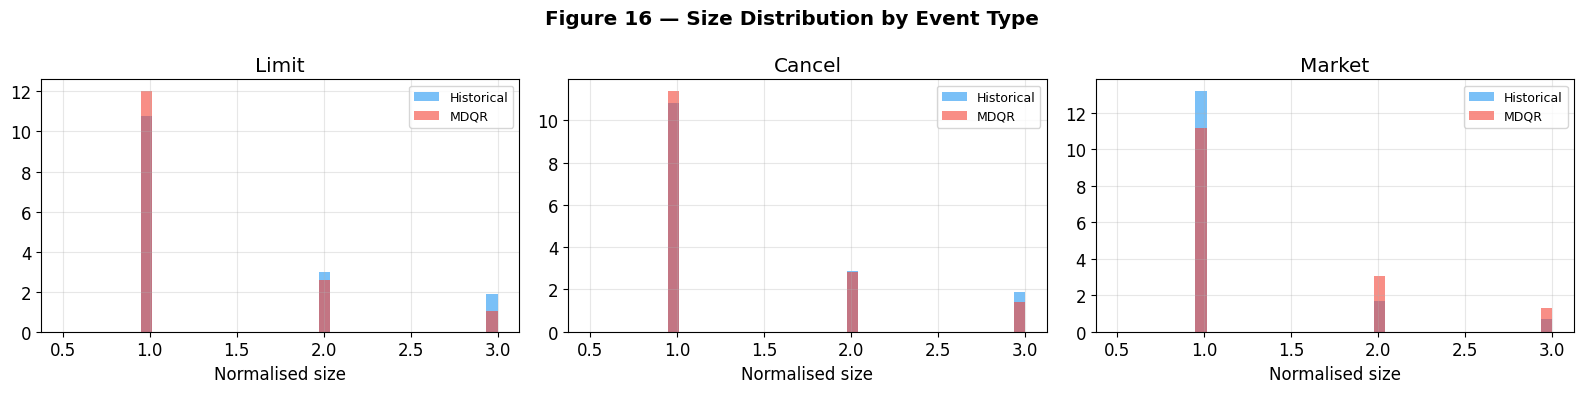

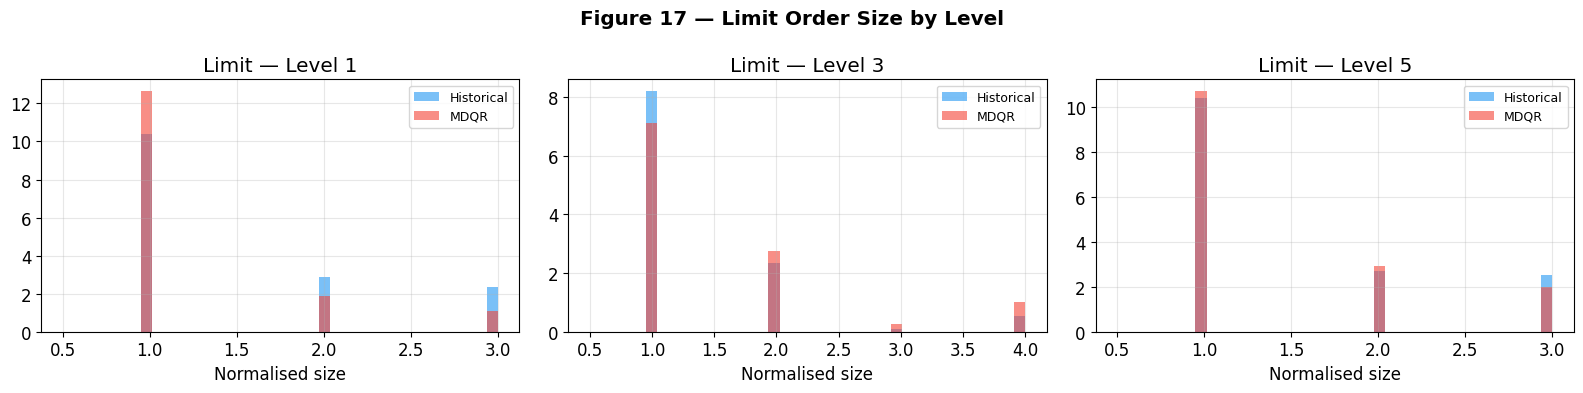

NameError: name 'Xg_s_va' is not defined

In [29]:
def get_sizes_by(df, cond_col, cond_val):
    s = df[df[cond_col] == cond_val]['size'].dropna().astype(float).values
    return s[s > 0]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (et, name) in zip(axes, [('L','Limit'),('C','Cancel'),('M','Market')]):
    r = get_sizes_by(df_norm, 'type', et)
    s = get_sizes_by(df_sim,  'type', et)
    mx = np.percentile(r, 95) if len(r) > 0 else 10.0
    bins = np.linspace(0.5, mx, 40)
    if len(r) > 0: ax.hist(r, bins=bins, density=True, alpha=0.6, color='#2196F3', label='Historical')
    if len(s) > 0: ax.hist(s, bins=bins, density=True, alpha=0.6, color='#F44336', label='MDQR')
    ax.set_xlabel('Normalised size'); ax.set_title(name); ax.legend(fontsize=9)
plt.suptitle('Figure 16 — Size Distribution by Event Type', fontweight='bold')
plt.tight_layout(); plt.savefig('fig16_size_type.pdf', dpi=150); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, lv in zip(axes, [1, 3, 5]):
    r = df_norm[(df_norm['type']=='L') & (df_norm['lvl'].abs()==lv)]['size'].dropna().astype(float).values
    s = df_sim[ (df_sim['type']=='L')  & (df_sim['lvl'].abs()==lv)]['size'].dropna().astype(float).values
    r = r[r > 0]; s = s[s > 0]
    mx = np.percentile(r, 95) if len(r) > 0 else 10.0
    bins = np.linspace(0.5, mx, 40)
    if len(r) > 0: ax.hist(r, bins=bins, density=True, alpha=0.6, color='#2196F3', label='Historical')
    if len(s) > 0: ax.hist(s, bins=bins, density=True, alpha=0.6, color='#F44336', label='MDQR')
    ax.set_xlabel('Normalised size'); ax.set_title(f'Limit — Level {lv}'); ax.legend(fontsize=9)
plt.suptitle('Figure 17 — Limit Order Size by Level', fontweight='bold')
plt.tight_layout(); plt.savefig('fig17_size_level.pdf', dpi=150); plt.show()

# Figure 18: marginal distribution
r_all = df_norm['size'].dropna().astype(float).values; r_all = r_all[r_all > 0]
s_all = df_sim['size'].dropna().astype(float).values;  s_all = s_all[s_all > 0]
size_net.eval()
with torch.no_grad():
    n_samp = min(2000, len(Xc_s_va))
    # CRITICAL: Apply Softmax to raw logits BEFORE taking the mean over the batch!
    logits = size_net(Xc_s_va[:n_samp].to(device), Xh_s_va[:n_samp].to(device),
                      Xl_s_va[:n_samp].to(device), Xg_s_va[:n_samp].to(device), Xj_s_va[:n_samp].to(device))
    avg_p  = torch.softmax(logits, dim=-1).cpu().numpy().mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mx = np.percentile(r_all, 95) if len(r_all) > 0 else 10.0
bins = np.linspace(0.5, mx, 50)
if len(r_all) > 0: axes[0].hist(r_all, bins=bins, density=True, alpha=0.6, color='#2196F3', label='Historical')
if len(s_all) > 0: axes[0].hist(s_all, bins=bins, density=True, alpha=0.6, color='#F44336', label='MDQR sim.')

# Plotting the 200 integer size classes directly
classes = np.arange(1, len(avg_p) + 1)
axes[0].bar(classes, avg_p, width=1.0, alpha=0.35, color='purple', label='SizeNet (avg)')
axes[0].set_xlim(0, mx) # Focus plot on the 95th percentile bulk

axes[0].set_xlabel('Normalised size'); axes[0].set_ylabel('Density')
axes[0].set_title('Marginal Size Distribution'); axes[0].legend(fontsize=9)

if len(s_all) > 10 and len(r_all) > 10:
    qs2 = np.linspace(0.01, 0.99, 100)
    axes[1].plot(np.quantile(r_all, qs2), np.quantile(s_all, qs2), '.', color='#F44336', ms=4)
    d2 = [0, max(np.quantile(r_all, 0.99), np.quantile(s_all, 0.99))]
    axes[1].plot(d2, d2, 'k--', lw=1)
axes[1].set_xlabel('Historical quantiles'); axes[1].set_ylabel('MDQR quantiles')
axes[1].set_title('Q–Q: Marginal Size')
plt.suptitle('Figure 18 — Stationary Order Size Distribution', fontweight='bold')
plt.tight_layout(); plt.savefig('fig18_size_marginal.pdf', dpi=150); plt.show()

print("=" * 60)
print("DIAGNOSTIC — Figs 16-18 (size distributions)")
for t in ['L','C','M']:
    r = get_sizes_by(df_norm, 'type', t); s = get_sizes_by(df_sim, 'type', t)
    if len(r) > 0 and len(s) > 0:
        print(f"  {t}: real mean={r.mean():.3f} med={np.median(r):.3f} | "
              f"sim  mean={s.mean():.3f} med={np.median(s):.3f}")
print("=" * 60)

---
## 15. Summary

### What the MDQR model achieves over DQR

The MDQR model relaxes three independence assumptions that are hard-coded into the per-queue DQR:

1. **Cross-level intensities.** Because all $2K$ queue sizes enter $\mathbf{x}_k$, the arrival
   rate at level $i$ can depend on the state of levels $j \neq i$.  This is structurally
   impossible for single-queue DQR models.

2. **Joint calibration of $3 \times 2K = 30$ intensities.** One shared network captures how
   the full LOB state drives event activity, enabling the model to learn, for example, that
   a thin ask queue at level 1 simultaneously raises the probability of a buy market order and
   lowers the probability of new ask limit orders.

3. **Order size distribution.** SizeNet provides a complete conditional distribution over
   normalised order sizes, replacing the unit-size assumption of QR/DQR.

### Checklist against the paper (Section 4)

| Specification | This notebook |
|---------------|---------------|
| Architecture [256, 64], Tanh, ReLU/Softmax (Table 4) | ✓ |
| Global $\Delta t_k$: training clip $[1\,\mu\text{s}, 30\,\text{s}]$; timing metric filter $> 1\,\text{ms}$ | ✓ |
| SizeNet with categorical cross-entropy (Section 4.1) | ✓ |
| Adam + CAWR $[10^{-5}, 10^{-3}]$, patience 30 (single-day adaptation from paper's 10) | ✓ |
| Random 80/20 train/val split | ✓ |
| Figures 5, 9–18 | ✓ |

### Known limitations & Deviations from the Paper

Although this implementation of the MDQR model successfully incorporates the core innovations of Bodor & Carlier (2025) — including joint queue modeling, Trade Imbalances ($TI_\tau$), and exact conditional order-size distributions — a few structural adaptations were necessary:

1. **Dataset Size and Asset Class:** The original paper calibrates the model on 3 months of Eurex Bund futures data (highly liquid, thick queues). This notebook uses a single trading day of NASDAQ INTC equities (thinner queues, different microstructural dynamics). Consequently, the model may exhibit higher variance and requires stronger regularization/patience.

2. **Global vs. Local Event Embedding ($e(t_k)$):**
   The paper tracks the most recent event type *at each specific price level* $e_i(t_k)$ to feed into the network. To prevent severe overfitting on a single-day dataset, this implementation simplifies the state space by tracking only the single, global most recent event $e(t_k)$ across the entire limit order book.

3. **Early Stopping Patience:**
   The paper utilizes a patience of 10 epochs for early stopping. Due to the high noise associated with single-day equity data, we increased the patience to 30 epochs (`PATIENCE = 30`) to prevent premature termination during training.

4. **Simulation Engine & Price Dynamics:**
   Our Gillespie simulation engine uses a simplified rule for mid-price updates: the price shifts only when a level-1 queue is completely depleted. A fully realistic matching engine (as hinted in the paper) would also process limit orders placed *inside* the bid-ask spread, directly narrowing the spread and updating the mid-price without requiring full depletion.